# Transit Anomaly Detection for Airport and Border Control Data

**Machine Learning Project — Academic Year 2025/26**
**Company brief:** Whitehall Reply — Project 2 *(Classical vs Multi-Agent anomaly detection)*

**Team members**    - Giulio D'Amico    - Alexis Mitracos
---

## Project scope

Border-control authorities and airport operators handle large volumes of passenger transits daily, with rich metadata attached to each event (timestamp, gate, route, nationality, document type, control outcome, alert flags). Today, anomaly detection on such data is mostly reactive. The goal of this project is to implement the same anomaly-detection system twice — once as a **classical pipeline** and once as a **multi-agent architecture** — and to produce a comparative analysis identifying the operational conditions under which each approach is preferable.

## Notebook Index

1. Setup and data loading
2. Data-quality audit
3. Univariate analysis
4. Bivariate analysis
5. Multivariate analysis
6. Outlier analysis
7. Feature engineering
8. Anomaly detection
9. Post processing
10. Conclusions and next steps


## 1. Setup and data loading

### 1.1 Imports and plotting defaults

We load the scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`), `missingno` for missing-value diagnostics, `pycountry` for ISO country-code normalisation, and `re` for the regex-based date parsing used in the cleaning block. Plotting defaults are set globally so that every figure in the notebook shares the same style.


In [85]:
import time, warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from IPython.display import display

from utils import (
    RANDOM_STATE, CONTAMINATION, SIGNAL_CAP, DISQUALIFYING_FLAGS,
    load_clean_data, build_route_master, build_feature_matrix,
    fit_detectors, wilson_ci, quality_note, apply_post_processing,
)

# Plotting defaults (locali al notebook)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"]    = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE = \
    "#1A3764", "#4682B4", "#E8735A", "#27AE60", "#000000", \
    "#E74C3C", "#F1C40F", "#A2D2FF", "#8B4513", "#FF69B4"
PALETTE = [NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE]

start_time = time.time()

### 1.2 Reference mappings

Reference mappings are imported from utils.py to guarantee identical cleaning across the classical and multi-agent pipelines.

### 1.3 Load raw CSVs

We read both CSVs and apply the IT-to-EN column rename in a single step. We keep two separate DataFrames (`df_alarms`, `df_travelers`) because they describe two different observation units — alarm events vs. traveler-category daily aggregates — and share only a subset of columns.


In [86]:
df_alarms = pd.read_csv("io/ALLARMI.csv")
df_travelers = pd.read_csv("io/TIPOLOGIA_VIAGGIATORE.csv")
print(f"Alarms    : {df_alarms.shape[0]:,} rows × {df_alarms.shape[1]} cols")
print(f"Travelers : {df_travelers.shape[0]:,} rows × {df_travelers.shape[1]} cols")

Alarms    : 5,080 rows × 24 cols
Travelers : 5,095 rows × 33 cols


## 2. Data-quality audit

### 2.1 Raw dataset inspection

Before any cleaning we profile both datasets: shape, column dtypes, per-column missingness (count and percentage), and cardinality. A snapshot of the raw missing counts and of the raw column set is stored in memory so that section 2.8 can produce a rigorous before/after comparison.


In [87]:
def inspect_dataset(df, dataset_name):
    """Print shape, dtype, missing count, missing %, and cardinality for each column."""
    print(f"\n{'='*60}\n  {dataset_name}\n{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
    overview = pd.DataFrame({
        "Dtype":       df.dtypes,
        "Missing":     df.isnull().sum(),
        "Missing %":   (df.isnull().sum() / len(df) * 100).round(2),
        "Cardinality": df.nunique(),
    })
    print("Column-level overview:")
    display(overview)

inspect_dataset(df_alarms,    "ALARMS (ALLARMI)")
inspect_dataset(df_travelers, "TRAVELERS (TIPOLOGIA_VIAGGIATORE)")


  ALARMS (ALLARMI)
Shape: 5,080 rows x 24 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
OCCORRENZE,object,0,0.00,30
AREOPORTO_ARRIVO,object,0,0.00,77
AREOPORTO_PARTENZA,object,0,0.00,208
ANNO_PARTENZA,object,0,0.00,5
MESE_PARTENZA,object,0,0.00,14
DATA_PARTENZA,object,0,0.00,3810
DESCR_AEREOPORTO_ARR,object,0,0.00,31
DESCR_AEREOPORTO_PART,object,109,2.15,136
CITTA_ARR,object,0,0.00,29
CITTA_PARTENZA,object,101,1.99,110



  TRAVELERS (TIPOLOGIA_VIAGGIATORE)
Shape: 5,095 rows x 33 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
NAZIONALITA,object,116,2.28,19
AREOPORTO_ARRIVO,object,0,0.00,79
AREOPORTO_PARTENZA,object,0,0.00,242
ANNO_PARTENZA,object,0,0.00,4
MESE_PARTENZA,object,0,0.00,5
GIORNO_PARTENZA,int64,0,0.00,31
DATA_PARTENZA,object,0,0.00,3977
DESCR_AEREOPORTO_ARR,object,0,0.00,29
DESCR_AEREOPORTO_PART,object,0,0.00,176
CITTA_ARR,object,0,0.00,27


The two missingness bar-charts below provide a visual snapshot of data completeness *before* cleaning. Longer bars indicate more complete columns; short ones flag fields that will require imputation or domain-specific treatment downstream.


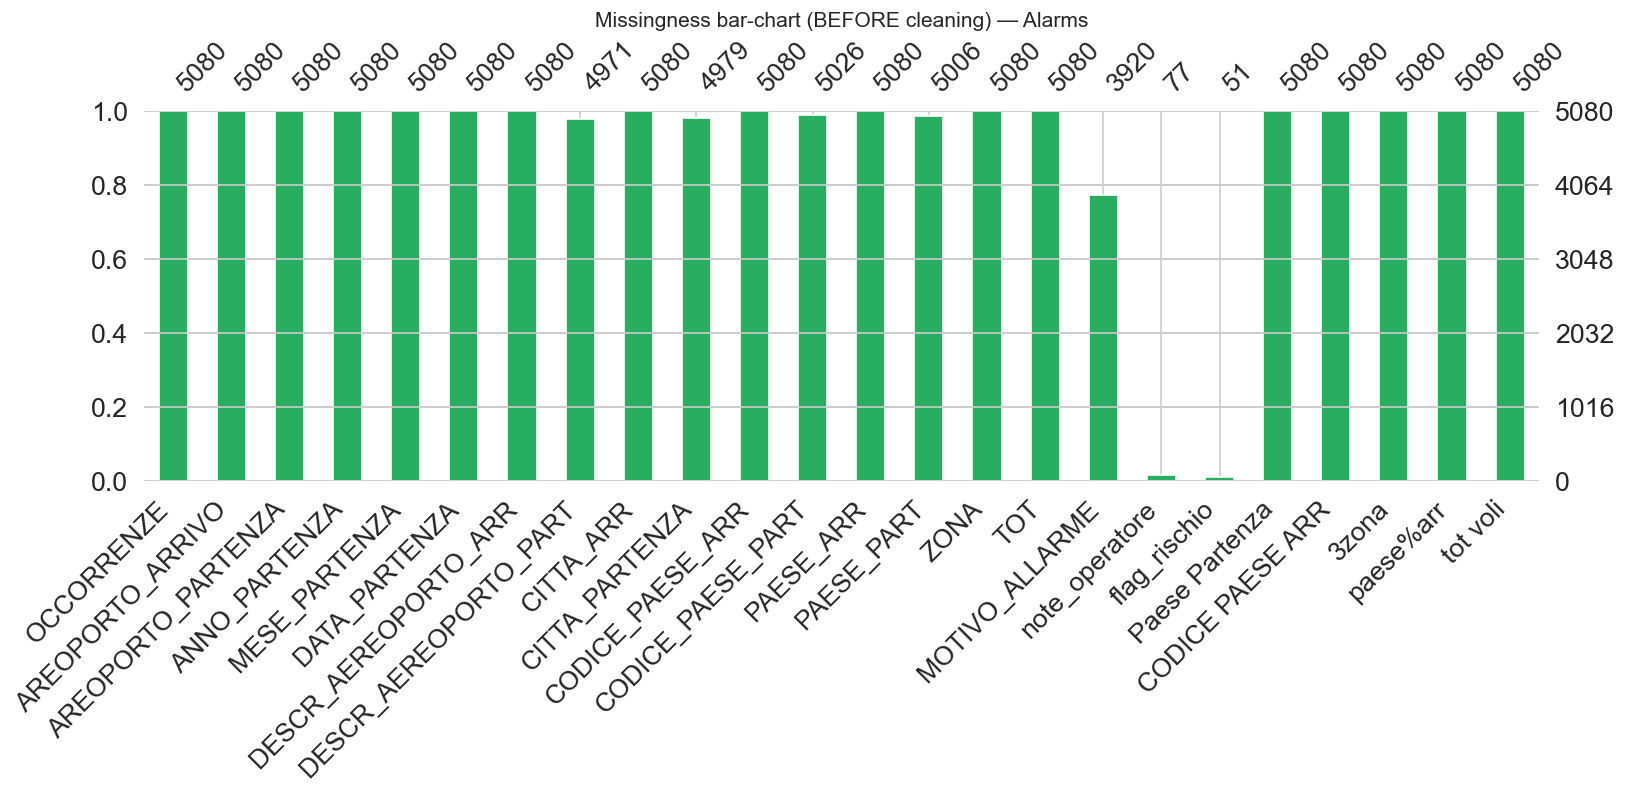

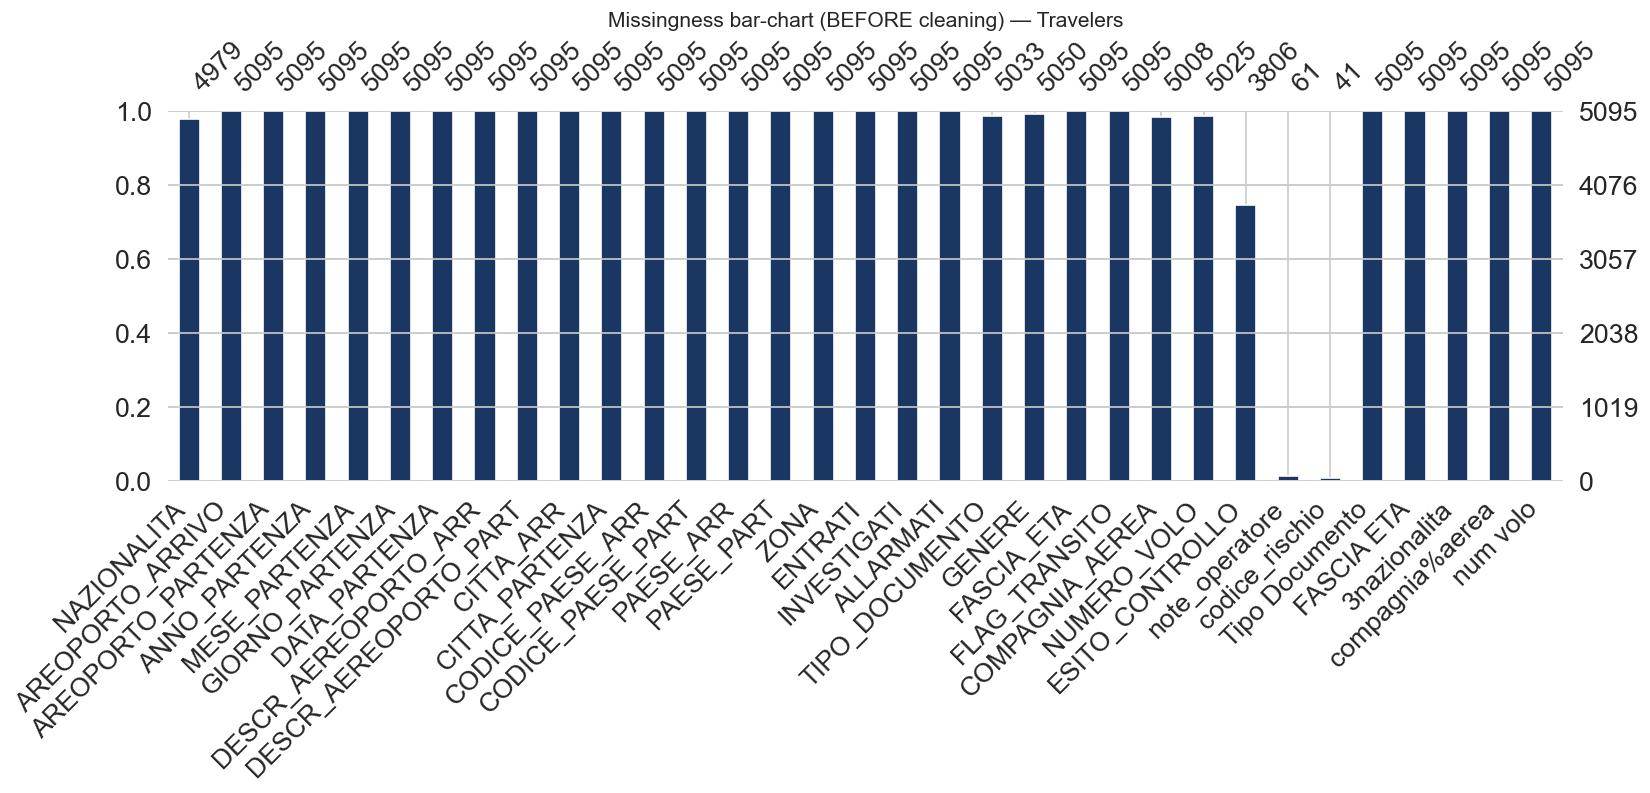

In [88]:
msno.bar(df_alarms, figsize=(15, 4), color=GREEN)
plt.title("Missingness bar-chart (BEFORE cleaning) — Alarms")
plt.show()

msno.bar(df_travelers, figsize=(15, 4), color="#1A3764")
plt.title("Missingness bar-chart (BEFORE cleaning) — Travelers")
plt.show()

raw_missing_alarms    = df_alarms.isnull().sum().copy()
raw_missing_travelers = df_travelers.isnull().sum().copy()
raw_shape_alarms      = df_alarms.shape
raw_shape_travelers   = df_travelers.shape

### 2.2 Categorical-cardinality inspection

We split categorical columns into two buckets: *low-cardinality* (≤ 400 unique values, amenable to visual inspection and rule-based cleanup) and *high-cardinality* (> 400, which will require grouping or encoding). We plot only the first group so the chart stays readable, and print the high-cardinality columns as an early warning. Cardinality > 15 is also flagged in coral as a soft threshold for downstream one-hot encoding.

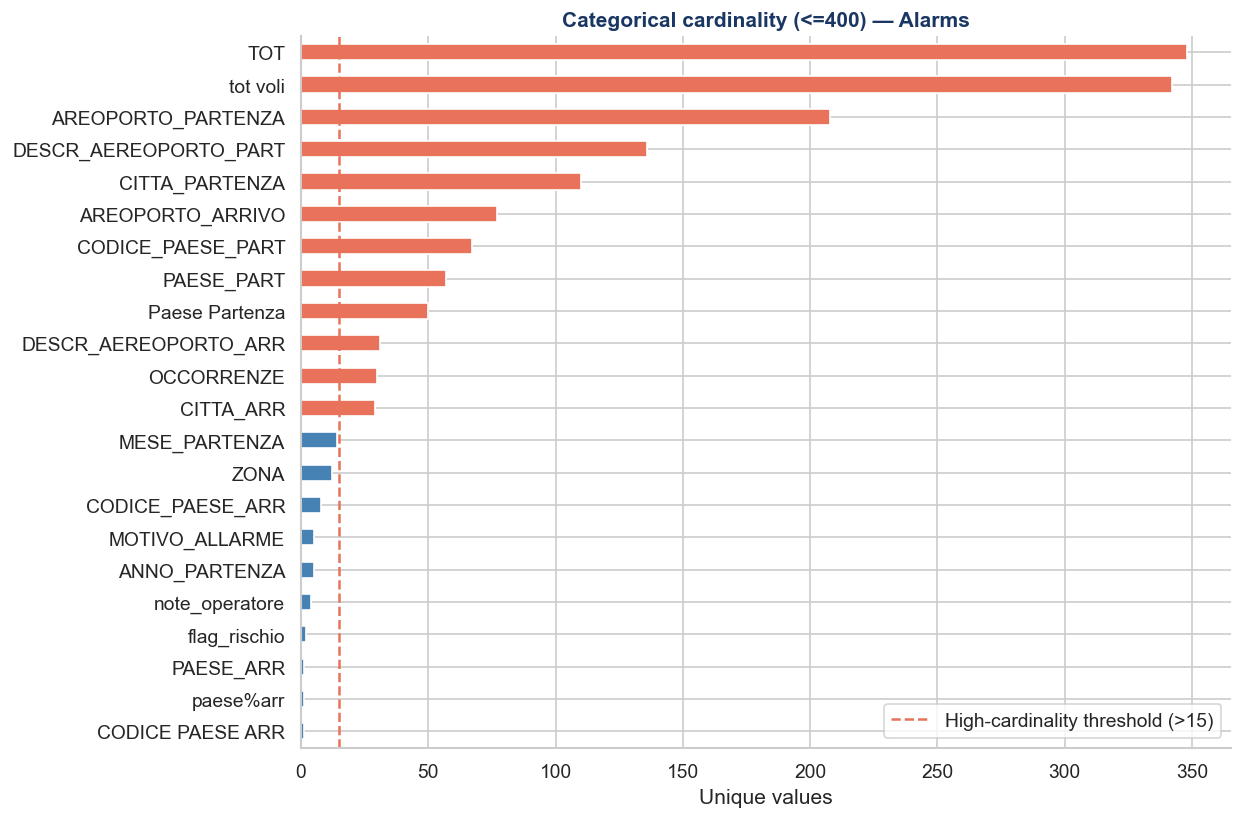

HIGH-CARDINALITY features (excluded from chart):
    'DATA_PARTENZA': 3810 unique values — needs grouping/target encoding

  Reviewing unique values (Alarms):
  'CODICE PAESE ARR' (1 values): ['ITA']

  'paese%arr' (1 values): ['Italia']

  'PAESE_ARR' (1 values): ['Italia']

  'flag_rischio' (2 values): ['ALTO', 'MEDIO']

  'note_operatore' (4 values): ['Alert manuale', 'Doppio controllo', 'Passeggero noto', 'Verifica richiesta']

  'ANNO_PARTENZA' (5 values): ['2023', '2024', '2024.', '24', 'anno 2024']

  'MOTIVO_ALLARME' (5 values): ['INTERPOL', 'Manuale', 'NSIS', 'SDI', 'TSC']

  'CODICE_PAESE_ARR' (8 values): ['DEU', 'ESP', 'FRA', 'GB', 'GBR', 'IT', 'ITA', 'TUR']

  'ZONA' (12 values): ['-1', '1', '10', '2', '4', '5', '6', '7', '8', '9', '99', '??']

  'MESE_PARTENZA' (14 values): ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', 'FEB', 'GEN']

  'CITTA_ARR' (29 values): ['Ancona', 'Bari', 'Bergamo', 'Bologna', 'Bolzano', 'Brescia', 'Brindisi', 'Cagliari', 

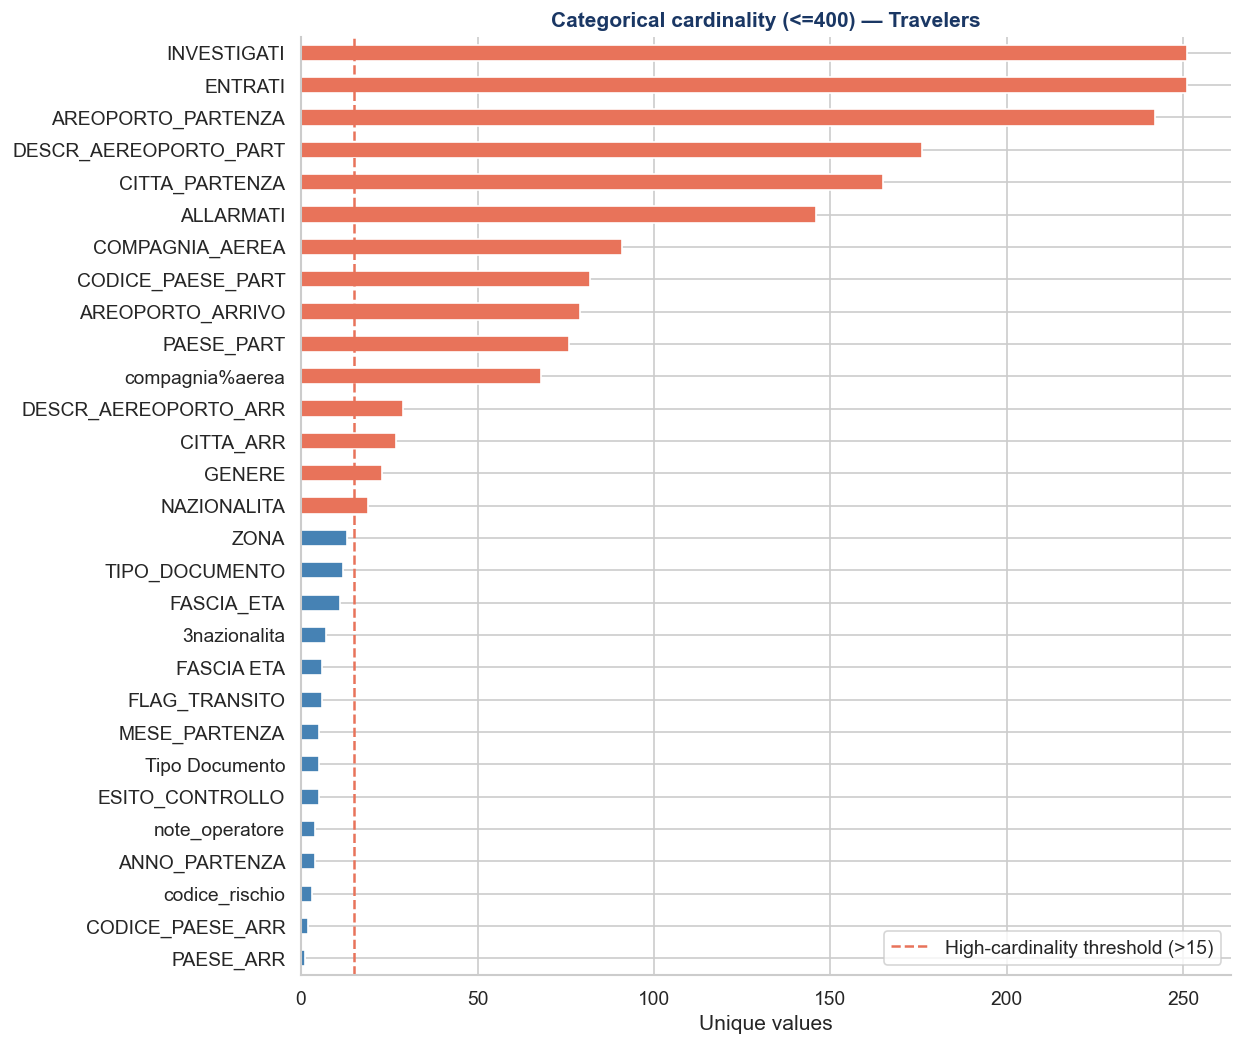

HIGH-CARDINALITY features (excluded from chart):
    'NUMERO_VOLO': 701 unique values — needs grouping/target encoding
    'num volo': 706 unique values — needs grouping/target encoding
    'DATA_PARTENZA': 3977 unique values — needs grouping/target encoding

  Reviewing unique values (Travelers):
  'PAESE_ARR' (1 values): ['Italia']

  'CODICE_PAESE_ARR' (2 values): ['IT', 'ITA']

  'codice_rischio' (3 values): ['R1', 'R2', 'R3']

  'ANNO_PARTENZA' (4 values): ['2023', '2024', '24', 'anno 2024']

  'note_operatore' (4 values): ['Alert manuale', 'Passeggero noto', 'Segnalazione esterna', 'Verifica richiesta']

  'ESITO_CONTROLLO' (5 values): ['FERMATO', 'IN ATTESA', 'OK', 'RESPINTO', 'SEGNALATO']

  'Tipo Documento' (5 values): ["Carta d'identità", 'N.D.', 'Passaporto', 'Permesso di soggiorno', 'Visto']

  'MESE_PARTENZA' (5 values): ['01', '02', '12', 'FEB', 'GEN']

  'FLAG_TRANSITO' (6 values): ['Multitratta', 'N/C', 'Singola Tratta', 'TRANSITO', 'Tripla Tratta', 'singola tratta']

 

In [89]:
def inspect_categorical(df, dataset_name):
    """Separate low- and high-cardinality categoricals, plot the former, list the latter."""
    cat_cols = df.select_dtypes(include=["object"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(df_alarms,    "Alarms")
inspect_categorical(df_travelers, "Travelers")

### 2.2.5 Distribution of signal columns and justification of [0, 200] cap

Before the cleaning truncates `ENTRIES`, `INVESTIGATED`, and `ALARMS` to the
range `[0, 200]`, we inspect the raw distributions to motivate the cap. The
chosen cutoff must (a) preserve the bulk of the legitimate signal,
(b) exclude only values that are clearly artefacts (parsing errors, free-text
notes coerced to numerics, decimal separators misread as digits).

Quantiles per signal column (raw, before cap):
      ENTRATI  INVESTIGATI  ALLARMATI
0.50     3.00         2.00       1.00
0.95   128.00       127.00      22.00
0.99   157.00       157.00      84.00
0.99   166.00       165.30     108.60
1.00   185.00       185.10     138.80
1.00 10000.00      9999.00    5000.00


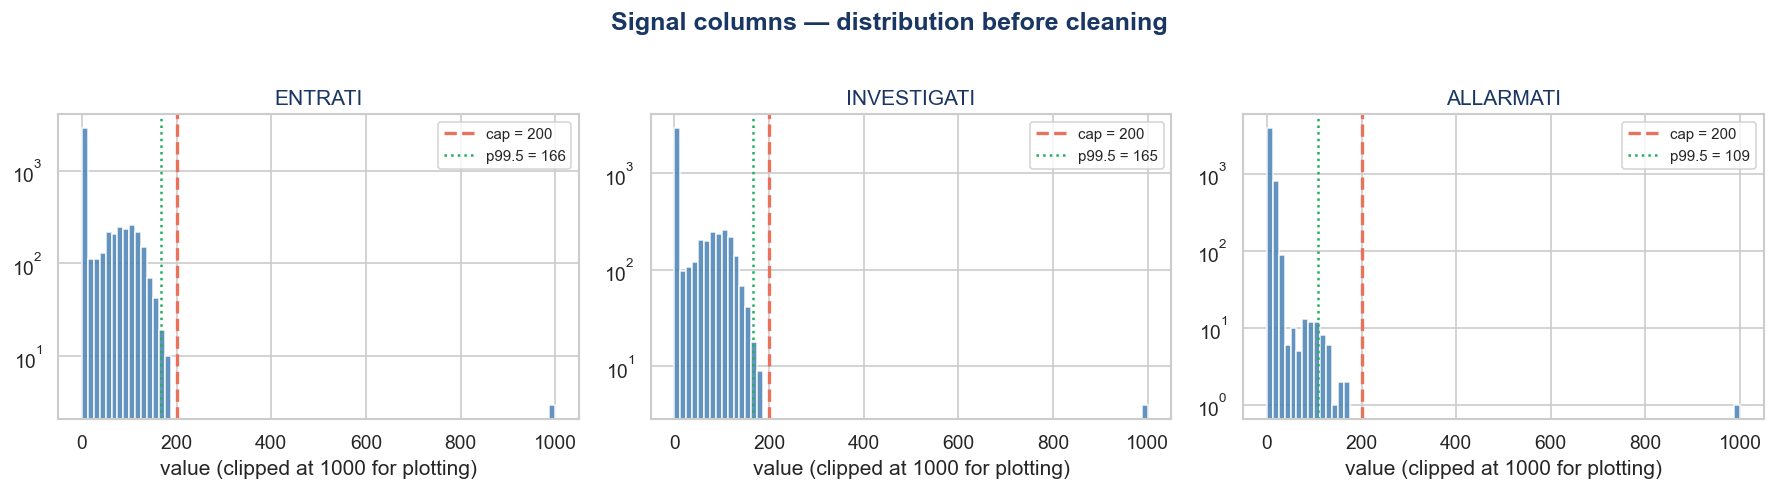


Row retention by cap (rows with all 3 signals ∈ [0, cap]):
  cap =  100 → 4,143 / 5,095 (81.32%)
  cap =  150 → 4,806 / 5,095 (94.33%)
  cap =  200 → 4,877 / 5,095 (95.72%)
  cap =  300 → 4,877 / 5,095 (95.72%)
  cap =  500 → 4,877 / 5,095 (95.72%)
  cap = 1000 → 4,877 / 5,095 (95.72%)


In [90]:
# Re-read raw signals to inspect the pre-cap distribution
_raw_t = pd.read_csv("io/TIPOLOGIA_VIAGGIATORE.csv")
_signal_cols = [c for c in ("ENTRATI", "INVESTIGATI", "ALLARMATI") if c in _raw_t.columns]

_signals_raw = (_raw_t[_signal_cols]
                .apply(lambda s: s.astype(str)
                                  .str.replace(r"(?i)pax", "", regex=True)
                                  .str.replace(r"\s+",   "", regex=True))
                .apply(pd.to_numeric, errors="coerce"))

# Quantiles inform the cap
qs = _signals_raw.quantile([0.50, 0.95, 0.99, 0.995, 0.999, 1.0]).round(1)
print("Quantiles per signal column (raw, before cap):")
print(qs.to_string())

# Visual: log-scale histogram + cap line
fig, axes = plt.subplots(1, len(_signal_cols), figsize=(5*len(_signal_cols), 4))
if len(_signal_cols) == 1: axes = [axes]
for ax, c in zip(axes, _signal_cols):
    s = _signals_raw[c].dropna()
    s_pos = s[s >= 0]
    ax.hist(np.clip(s_pos, 0, 1000), bins=80, color=STEEL, edgecolor="white", alpha=0.85)
    ax.axvline(SIGNAL_CAP, color=CORAL, ls="--", lw=2, label=f"cap = {SIGNAL_CAP}")
    p995 = s_pos.quantile(0.995)
    ax.axvline(p995, color=GREEN, ls=":", lw=1.5, label=f"p99.5 = {p995:.0f}")
    ax.set_yscale("log")
    ax.set_title(c, color=NAVY)
    ax.set_xlabel("value (clipped at 1000 for plotting)")
    ax.legend(fontsize=9)
plt.suptitle("Signal columns — distribution before cleaning",
             fontweight="bold", color=NAVY, y=1.02)
plt.tight_layout(); plt.show()

# How many rows would each candidate cap retain?
print(f"\nRow retention by cap (rows with all 3 signals ∈ [0, cap]):")
mask_all = lambda cap: (_signals_raw.iloc[:, 0].between(0, cap) &
                        _signals_raw.iloc[:, 1].between(0, cap) &
                        _signals_raw.iloc[:, 2].between(0, cap))
for cap in (100, 150, 200, 300, 500, 1000):
    keep = mask_all(cap).sum()
    print(f"  cap = {cap:>4} → {keep:,} / {len(_signals_raw):,} "
          f"({100*keep/len(_signals_raw):5.2f}%)")

del _raw_t, _signals_raw

### 2.3 / 2.4 Travelers + Alarms cleaning

Both cleaning routines have been factored out into `utils._clean_travelers`
and `utils._clean_alarms`, called transparently by `load_clean_data()` in
§1.3.   

In [91]:
df_alarms, df_travelers = load_clean_data()
print(f"Cleaned Alarms    : {df_alarms.shape[0]:,} rows × {df_alarms.shape[1]} cols")
print(f"Cleaned Travelers : {df_travelers.shape[0]:,} rows × {df_travelers.shape[1]} cols")

Cleaned Alarms    : 5,048 rows × 19 cols
Cleaned Travelers : 4,840 rows × 26 cols


### 2.3 Travelers cleaning and standardisation

The cleaning covers six areas. Departure and arrival columns are normalised
via the `iata_mapping` and `it_to_alpha3` dictionaries — IATA codes are
uppercased and stripped, city and airport descriptions are back-filled from
the mapping, and country codes are derived programmatically. Redundant column
pairs (`AGE_GROUP`/`AGE_GROUP2`, `DOCUMENT_TYPE`/`DOCUMENT_TYPE2`,
`AIRLINE`/`AIRLINE%`, `FLIGHT_NUMBER`/`FLIGHT NUMBER`) are resolved by
keeping the cleaner column and dropping the other after confirming equivalence.
`DEPARTURE_YEAR` and `DEPARTURE_MONTH` are dropped as derivable from
`DEPARTURE_DATE`. Categorical fields (`GENDER`, `TRANSIT_FLAG`,
`OPERATOR_NOTES`, `NATIONALITY`) are uppercased, unknown tokens unified, and
placeholders applied. Signal columns (`ENTRIES`, `INVESTIGATED`, `ALARMS`)
are cast to integer after stripping unit suffixes; rows outside `[0, 200]`
are dropped as implausible.

### 2.4 Alarms cleaning and standardisation

Redundant and derivable columns are dropped first (`DEPARTURE_MONTH`,
`DEPARTURE_YEAR`, `ARRIVAL_COUNTRY_CODE`,`ARRIVAL_COUNTRY_CODE_PERCENTAGE`).
`OCCURRENCES` is mapped to a controlled English vocabulary via `occurrences_map`.
`ZONE` is cast to integer after nullifying sentinel values (`-1`, `99`, `??`),merged with `ZONE_3` via `combine_first`, and `ZONE_3` is dropped.
`ALARM_REASON` and `OPERATOR_NOTES` are uppercased with explicit placeholders for missing values. `RISK_FLAG` is translated from Italian (`ALTO`→`HIGH RISK`,`MEDIO`→`MEDIUM RISK`) and NaN filled with `LOW RISK`. Departure and arrival columns are normalised via `iata_mapping`; country codes are derived from the most complete country column via `it_to_alpha3`. `TOTAL` is dropped in favour of the cleaner `TOTAL_FLIGHTS` column after numeric standardisation. 

### 2.5 Date parsing & temporal alignment

The two datasets use *different* date conventions, and the Alarms file in particular mixes at least six formats (`dd/mm/yyyy HH:MM:SS`, `yyyy/mm/dd`, `dd.mm.yyyy`, `MMM dd yyyy` with Italian month abbreviations, `dd-mm-yy`, …). We:

1. print the format distribution *before* cleaning by replacing digits with `N` and letters with `A` (a "pattern fingerprint" technique);
2. rewrite each known pattern to ISO 8601 via regex;
3. parse with `pd.to_datetime(..., errors='coerce')`;
4. print the fingerprint distribution *after* cleaning to verify every row now conforms.

In [92]:
def extract_pattern(val):
    s = re.sub(r"\d", "N", str(val))
    return re.sub(r"[a-zA-Z]", "A", s)

# Inspect formats AFTER
print("\nDate-format patterns AFTER cleaning:")
for name, df in [("Alarms", df_alarms), ("Travelers", df_travelers)]:
    counts = df["DEPARTURE_DATE"].dropna().astype(str).map(extract_pattern).value_counts()
    print(f"  {name}:\n    " + counts.to_string().replace("\n", "\n    "))


Date-format patterns AFTER cleaning:
  Alarms:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    5048
  Travelers:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    4840


### 2.6 Post-cleaning missing-value audit

A side-by-side table compares *per column* the number of missing values before and after section 2.3 – section 2.7. We only show rows where the count actually changed — the rest is untouched. The follow-up `missingno` bar-charts in green confirm visually that the key fields are now dense.


ALARMS  (shape: (5080, 24) -> (5048, 19))


,Missing BEFORE,Missing AFTER
Column,,
3zona,0,dropped
ALARM_REASON,—,0
ANNO_PARTENZA,0,dropped
AREOPORTO_ARRIVO,0,dropped
AREOPORTO_PARTENZA,0,dropped
ARRIVAL_AIRPORT_DESCRIPTION,—,0
ARRIVAL_AIRPORT_IATA,—,0
ARRIVAL_CITY,—,0
ARRIVAL_COUNTRY,—,0



TRAVELERS  (shape: (5095, 33) -> (4840, 26))


,Missing BEFORE,Missing AFTER
Column,,
3nazionalita,0,dropped
AGE_GROUP2,—,0
AIRLINE%,—,0
ALARMS,—,0
ALLARMATI,0,dropped
ANNO_PARTENZA,0,dropped
AREOPORTO_ARRIVO,0,dropped
AREOPORTO_PARTENZA,0,dropped
ARRIVAL_AIRPORT_DESCRIPTION,—,0


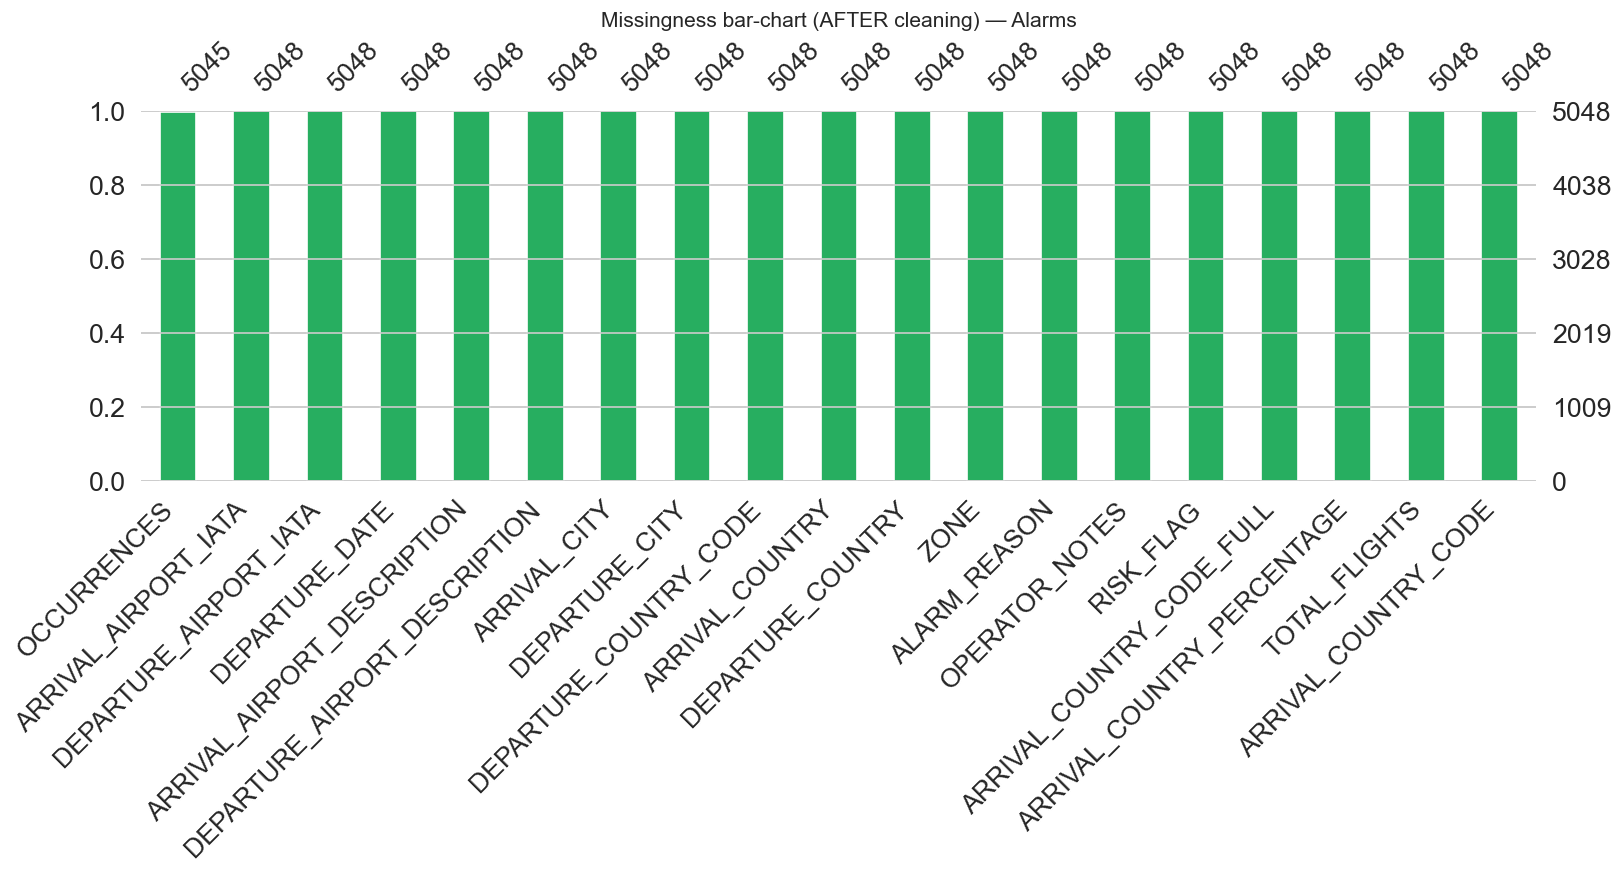

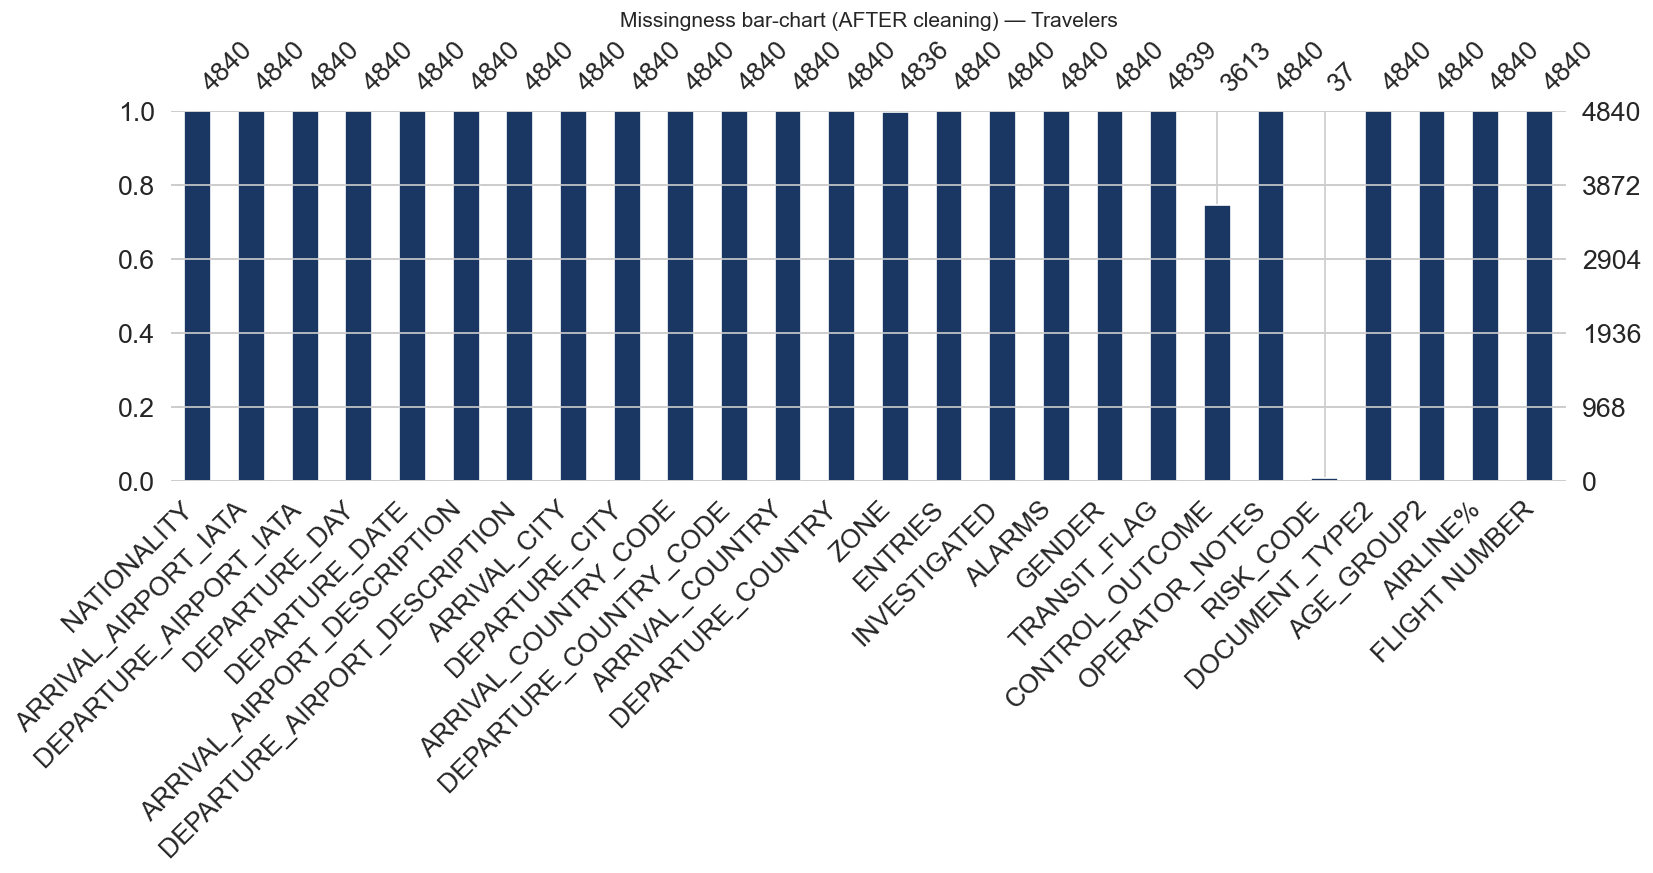

In [93]:
def missing_comparison(df_now, raw_missing, dataset_name, raw_shape):
    """Compare per-column missing-value counts before and after the cleaning pipeline."""
    now = df_now.isnull().sum()
    col_map = {c.upper(): c for c in df_now.columns}
    raw_missing = raw_missing.copy()
    raw_missing.index = [col_map.get(c.upper(), c) for c in raw_missing.index]
    all_cols = sorted(set(raw_missing.index) | set(now.index))
    rows = [{"Column": c,
             "Missing BEFORE": raw_missing.get(c, "—"),
             "Missing AFTER":  now.get(c, "dropped")} for c in all_cols]
    report = pd.DataFrame(rows).set_index("Column")
    print(f"\n{dataset_name}  (shape: {raw_shape} -> {df_now.shape})")
    display(report)

missing_comparison(df_alarms,    raw_missing_alarms,    "ALARMS",    raw_shape_alarms)
missing_comparison(df_travelers, raw_missing_travelers, "TRAVELERS", raw_shape_travelers)

msno.bar(df_alarms, figsize=(15, 4), color=GREEN)
plt.title("Missingness bar-chart (AFTER cleaning) — Alarms")
plt.show()

msno.bar(df_travelers, figsize=(15, 4), color="#1A3764")
plt.title("Missingness bar-chart (AFTER cleaning) — Travelers")
plt.show()

### 2.7 Final schema verification

We print the final shape, column list, and dtype counts for both datasets — the schema contract on which the feature-engineering block will depend. The cleaned DataFrames remain in memory (`df_alarms`, `df_travelers`); no disk persistence is required since the notebook runs end-to-end in a single session.


In [94]:
print(f"ALARMS -> {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} cols")
# order columns for better readability
cols_order = ['DEPARTURE_DATE', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_CITY', 'DEPARTURE_AIRPORT_DESCRIPTION', 'DEPARTURE_COUNTRY', 'DEPARTURE_COUNTRY_CODE', 
              'ARRIVAL_AIRPORT_IATA', 'ARRIVAL_CITY', 'ARRIVAL_AIRPORT_DESCRIPTION', 'ARRIVAL_COUNTRY', 'ARRIVAL_COUNTRY_CODE', 'ZONE',
               'OCCURRENCES', 'ALARM_REASON', 'OPERATOR_NOTES', 'RISK_FLAG', 'TOTAL_FLIGHTS']
df_alarms = df_alarms[cols_order + [col for col in df_alarms.columns if col not in cols_order]]
df_alarms.sample(5)

ALARMS -> 5,048 rows x 19 cols


,DEPARTURE_DATE,DEPARTURE_AIRPORT_IATA,DEPARTURE_CITY,DEPARTURE_AIRPORT_DESCRIPTION,DEPARTURE_COUNTRY,DEPARTURE_COUNTRY_CODE,ARRIVAL_AIRPORT_IATA,ARRIVAL_CITY,ARRIVAL_AIRPORT_DESCRIPTION,ARRIVAL_COUNTRY,ARRIVAL_COUNTRY_CODE,ZONE,OCCURRENCES,ALARM_REASON,OPERATOR_NOTES,RISK_FLAG,TOTAL_FLIGHTS,ARRIVAL_COUNTRY_CODE_FULL,ARRIVAL_COUNTRY_PERCENTAGE
2098,2024-02-24 08:25:00,IST,Istanbul,Istanbul Airport,Turchia,TUR,MXP,Milano,Malpensa,Italia,ITA,2,generated_alerts,SDI,NO MANUAL NOTES,LOW RISK,18,ITA,Italia
174,2024-02-15 11:50:00,TIA,Tirana,Rinas Mother Teresa,Albania,ALB,CTA,Catania,Fontanarossa,Italia,ITA,7,investigated_flights,SDI,NO MANUAL NOTES,LOW RISK,1,ITA,Italia
2854,2024-01-20 00:00:00,EDI,Edinburgh,Edinburgh Airport,Regno Unito,GBR,MXP,Milano,Malpensa,Italia,ITA,2,negative_outcome,TSC,NO MANUAL NOTES,LOW RISK,2,ITA,Italia
238,2024-02-27 13:20:00,RMO,Chisinau,Chisinau International,Moldavia,MDA,VCE,Venezia,Venezia Marco Polo,Italia,ITA,4,generated_alerts,SDI,NO MANUAL NOTES,LOW RISK,20,ITA,Italia
1359,2024-01-30 07:55:00,LGW,London,London Gatwick,Regno Unito,GBR,MXP,Milano,Malpensa,Italia,ITA,2,flights_with_alerts,MANUALE,NO MANUAL NOTES,LOW RISK,1,ITA,Italia


In [95]:
print(f"TRAVELERS -> {df_travelers.shape[0]:,} rows x {df_travelers.shape[1]} cols")
# order columns for better readability
cols_order = ['DEPARTURE_DATE', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_CITY', 'DEPARTURE_AIRPORT_DESCRIPTION', 'DEPARTURE_COUNTRY', 'DEPARTURE_COUNTRY_CODE', 
              'ARRIVAL_AIRPORT_IATA', 'ARRIVAL_CITY', 'ARRIVAL_AIRPORT_DESCRIPTION', 'ARRIVAL_COUNTRY', 'ARRIVAL_COUNTRY_CODE', 'ZONE', 
              'GENDER', 'NATIONALITY', 'TRANSIT_FLAG', 'RISK_CODE', 'CONTROL_OUTCOME', 'AGE_GROUP2', 'DOCUMENT_TYPE2', 'AIRLINE%', 'FLIGHT NUMBER', 'OPERATOR_NOTES', 'ENTRIES', 'INVESTIGATED', 'ALARMS']
df_travelers = df_travelers[cols_order + [col for col in df_travelers.columns if col not in cols_order]]
df_travelers.sample(5)

TRAVELERS -> 4,840 rows x 26 cols


,DEPARTURE_DATE,DEPARTURE_AIRPORT_IATA,DEPARTURE_CITY,DEPARTURE_AIRPORT_DESCRIPTION,DEPARTURE_COUNTRY,DEPARTURE_COUNTRY_CODE,ARRIVAL_AIRPORT_IATA,ARRIVAL_CITY,ARRIVAL_AIRPORT_DESCRIPTION,ARRIVAL_COUNTRY,ARRIVAL_COUNTRY_CODE,ZONE,GENDER,NATIONALITY,TRANSIT_FLAG,RISK_CODE,CONTROL_OUTCOME,AGE_GROUP2,DOCUMENT_TYPE2,AIRLINE%,FLIGHT NUMBER,OPERATOR_NOTES,ENTRIES,INVESTIGATED,ALARMS,DEPARTURE_DAY
267,2024-02-01 21:10:00,IST,Istanbul,Istanbul Airport,Turchia,TUR,FCO,Roma,Fiumicino,ITALY,ITA,5,M,ALB,1,NaN,IN ATTESA,18-30,Permesso di soggiorno,Turkish Airlines,TK1361,NO_NOTES,1,1,0,1
3580,2024-01-06 08:55:00,DXB,Dubai,Dubai International,Emirati Arabi Uniti,ARE,BLQ,Bologna,Guglielmo Marconi,ITALY,ITA,8,M,ALB,1,NaN,NaN,N.D.,Carta d'identità,Emirates,EK0093,NO_NOTES,1,4,0,6
1004,2024-02-16 08:35:00,STN,London,London Stansted,Regno Unito,GBR,MXP,Milano,Malpensa,ITALY,ITA,2,F,ALB,1,NaN,IN ATTESA,46-60,Permesso di soggiorno,Ryanair DAC,FR2757,NO_NOTES,1,1,0,16
1826,2024-02-15 05:35:00,TIA,Tirana,Rinas Mother Teresa,Albania,ALB,GOA,Genova,Cristoforo Colombo,ITALY,ITA,1,M,ALB,1,NaN,RESPINTO,61+,Permesso di soggiorno,ITA Airways,AZ 0507,NO_NOTES,2,3,0,15
2422,2024-02-11 06:00:00,RAK,Marrakech,Menara,Marocco,MAR,CIA,Roma,Ciampino,ITALY,ITA,5,N.D.,ALB,1,NaN,NaN,46-60,Passaporto,Ryanair DAC,FR-8114,NO_NOTES,1,1,0,11


### 2.8 Merging and consistency checks

The df_alarms dataset has a long structure: each row represents an event of type `OCCURRENCES` (closed alarms, available flights, investigated flights, etc.) with its count in `TOTAL_FLIGHTS`. The pivot flips the structure to a wide format: now each route has a numeric column for each type of occurrence (tot_closed_alarms, tot_available_flights, etc.). The fill_value=0 is semantic: if a route does not have that type of event, it is correctly zero.

In [96]:
alarms_pivot = (df_alarms
    .pivot_table(index=['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'],
                 columns='OCCURRENCES', values='TOTAL_FLIGHTS',
                 aggfunc='sum', fill_value=0))

alarms_pivot.columns = [f'tot_{c}' for c in alarms_pivot.columns]
alarms_pivot = alarms_pivot.reset_index()

alarms_desc = (df_alarms
    .groupby(['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'])
    .agg(DEPARTURE_CITY=('DEPARTURE_CITY','first'),
         DEPARTURE_COUNTRY=('DEPARTURE_COUNTRY','first'),
         DEPARTURE_COUNTRY_CODE=('DEPARTURE_COUNTRY_CODE','first'),
         ARRIVAL_CITY=('ARRIVAL_CITY','first'),
         ZONE=('ZONE', lambda s: s.mode().iat[0] if s.notna().any() else np.nan),
         n_high_risk=('RISK_FLAG', lambda s: (s == 'HIGH RISK').sum()),
         n_medium_risk=('RISK_FLAG', lambda s: (s == 'MEDIUM RISK').sum()),
         alarm_reason_top=('ALARM_REASON', lambda s: s.mode().iat[0] if s.notna().any() else np.nan))
    .reset_index())

df_alarms_route = alarms_pivot.merge(alarms_desc, on=['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'])
print(f'Alarms route-level: {df_alarms_route.shape}')

Alarms route-level: (368, 24)


### 2.8.1 Route-level aggregation — Travelers

The Travelers table is aggregated from individual passenger-category rows to
route-level summaries. Each `(DEPARTURE_AIRPORT_IATA, ARRIVAL_AIRPORT_IATA)`
group produces a single row with total entries, investigations, alarms, and
derived rates. Three additional feature families are added dynamically: per
top-nationality alert rates and volume shares, per top-document-type alert
rates, and per top-control-outcome frequency shares. These cross-sectional
features give the detectors signal beyond raw volumes, a route with an
unusual nationality mix or document-type pattern is anomalous in a different
way from a route that is simply busier than usual.

In [97]:
# Auto-detect top categories
top_nat = [v for v in df_travelers['NATIONALITY'].value_counts().head(3).index if v != 'N.D.'][:3]
top_doc = [v for v in df_travelers['DOCUMENT_TYPE2'].value_counts().head(3).index if v != 'N.D.'][:3]
top_co  = [v for v in df_travelers['CONTROL_OUTCOME'].value_counts().head(4).index if v != 'N.D.'][:4]
print(f'Top nationalities: {top_nat}\nTop document types: {top_doc}\nTop control outcomes: {top_co}')

def _safe_rate(num, den): return num/den if den > 0 else np.nan

def aggregate_travelers(g):
    inv, alm = g['INVESTIGATED'].sum(), g['ALARMS'].sum()
    out = {'tot_entries': g['ENTRIES'].sum(), 'tot_investigated': inv,
           'tot_alarms': alm, 'n_records': len(g),
}
    intensity = _safe_rate(alm, inv)
    out['alarm_intensity']    = intensity                              # raw, can exceed 1.0
    out['alert_rate']         = min(intensity, 1.0) if inv > 0 else np.nan  # capped, [0, 1]
    out['investigation_rate'] = _safe_rate(inv, g['ENTRIES'].sum())

    for nat in top_nat:
        sub = g[g['NATIONALITY'] == nat]
        out[f'alert_rate_{nat}'] = _safe_rate(sub['ALARMS'].sum(), sub['INVESTIGATED'].sum())
        out[f'pct_nat_{nat}'] = (g['NATIONALITY'] == nat).mean()
    for doc in top_doc:
        sub = g[g['DOCUMENT_TYPE2'] == doc]
        out[f'alert_rate_doc_{doc}'] = _safe_rate(sub['ALARMS'].sum(), sub['INVESTIGATED'].sum())
    co_norm = g['CONTROL_OUTCOME'].value_counts(normalize=True, dropna=True)
    for outcome in top_co:
        out[f'pct_{outcome}'] = co_norm.get(outcome, 0.0)
    return pd.Series(out)

df_trav_route = (df_travelers
    .groupby(['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'])
    .apply(aggregate_travelers).reset_index())
print(f'Travelers route-level: {df_trav_route.shape}')

Top nationalities: ['ALB', 'AFG', 'Unknown']
Top document types: ['Visto', 'Permesso di soggiorno']
Top control outcomes: ['SEGNALATO', 'IN ATTESA', 'RESPINTO', 'FERMATO']
Travelers route-level: (454, 21)


### 2.9 Route-level merge — Alarms and Travelers

The aggregated Alarms and Travelers route tables are joined on
`(DEPARTURE_AIRPORT_IATA, ARRIVAL_AIRPORT_IATA)` with an outer join to retain
routes present in only one source. The merge indicator confirms how many routes
are matched on both sides vs. single-source only. Numeric nulls introduced by
the outer join are filled with `0` — a route absent from one table genuinely
had zero activity on that side. The final `route` label column is added for
readability. The master route-level dataset is saved to
`io/ROUTE_LEVEL_DATA.csv`.

In [98]:
df_route = df_alarms_route.merge(
    df_trav_route, on=['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'],
    how='outer', indicator=True)

print(f"Routes total: {len(df_route)}")
print(df_route['_merge'].value_counts().to_string())

df_route = df_route.drop(columns='_merge')
num_cols = df_route.select_dtypes(include='number').columns
df_route[num_cols] = df_route[num_cols].fillna(0)
df_route['route'] = df_route['DEPARTURE_AIRPORT_IATA'] + '→' + df_route['ARRIVAL_AIRPORT_IATA']
display(df_route.head(3))

df_route.to_csv("io/ROUTE_LEVEL_DATA.csv", index=False)
print(f"\nRoute-level dataset {df_route.shape[0]} rows x {df_route.shape[1]} cols saved to 'io/ROUTE_LEVEL_DATASET.csv'.")

Routes total: 557
_merge
both          265
right_only    189
left_only     103


,DEPARTURE_AIRPORT_IATA,ARRIVAL_AIRPORT_IATA,tot_available_inbound_flights,tot_closed_alerts,tot_entries_x,tot_entries_with_alerts,tot_flights_with_alerts,tot_generated_alerts,tot_investigated_entries,tot_investigated_flights,tot_missing_update,tot_negative_outcome,tot_open_alerts,tot_other,tot_relevant_alerts,tot_viewed_not_investigated_flights,DEPARTURE_CITY,DEPARTURE_COUNTRY,DEPARTURE_COUNTRY_CODE,ARRIVAL_CITY,...,tot_entries_y,tot_investigated,tot_alarms,n_records,alarm_intensity,alert_rate,investigation_rate,alert_rate_ALB,pct_nat_ALB,alert_rate_AFG,pct_nat_AFG,alert_rate_Unknown,pct_nat_Unknown,alert_rate_doc_Visto,alert_rate_doc_Permesso di soggiorno,pct_SEGNALATO,pct_IN ATTESA,pct_RESPINTO,pct_FERMATO,route
0,ABJ,CAG,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,...,1.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,ABJ→CAG
1,ADB,BGY,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,...,1.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,ADB→BGY
2,ADB,FCO,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,ADB→FCO



Route-level dataset 557 rows x 44 cols saved to 'io/ROUTE_LEVEL_DATASET.csv'.


## 3. Univariate Analysis

### 3.1 Numerical distributions

For every numeric column we print the descriptive statistics (mean, std, quantiles) and draw a histogram. We use this to detect skewness (common for count data), bounded ranges (e.g. `zone`) and suspicious spikes at the extremes that may indicate residual data-quality issues.

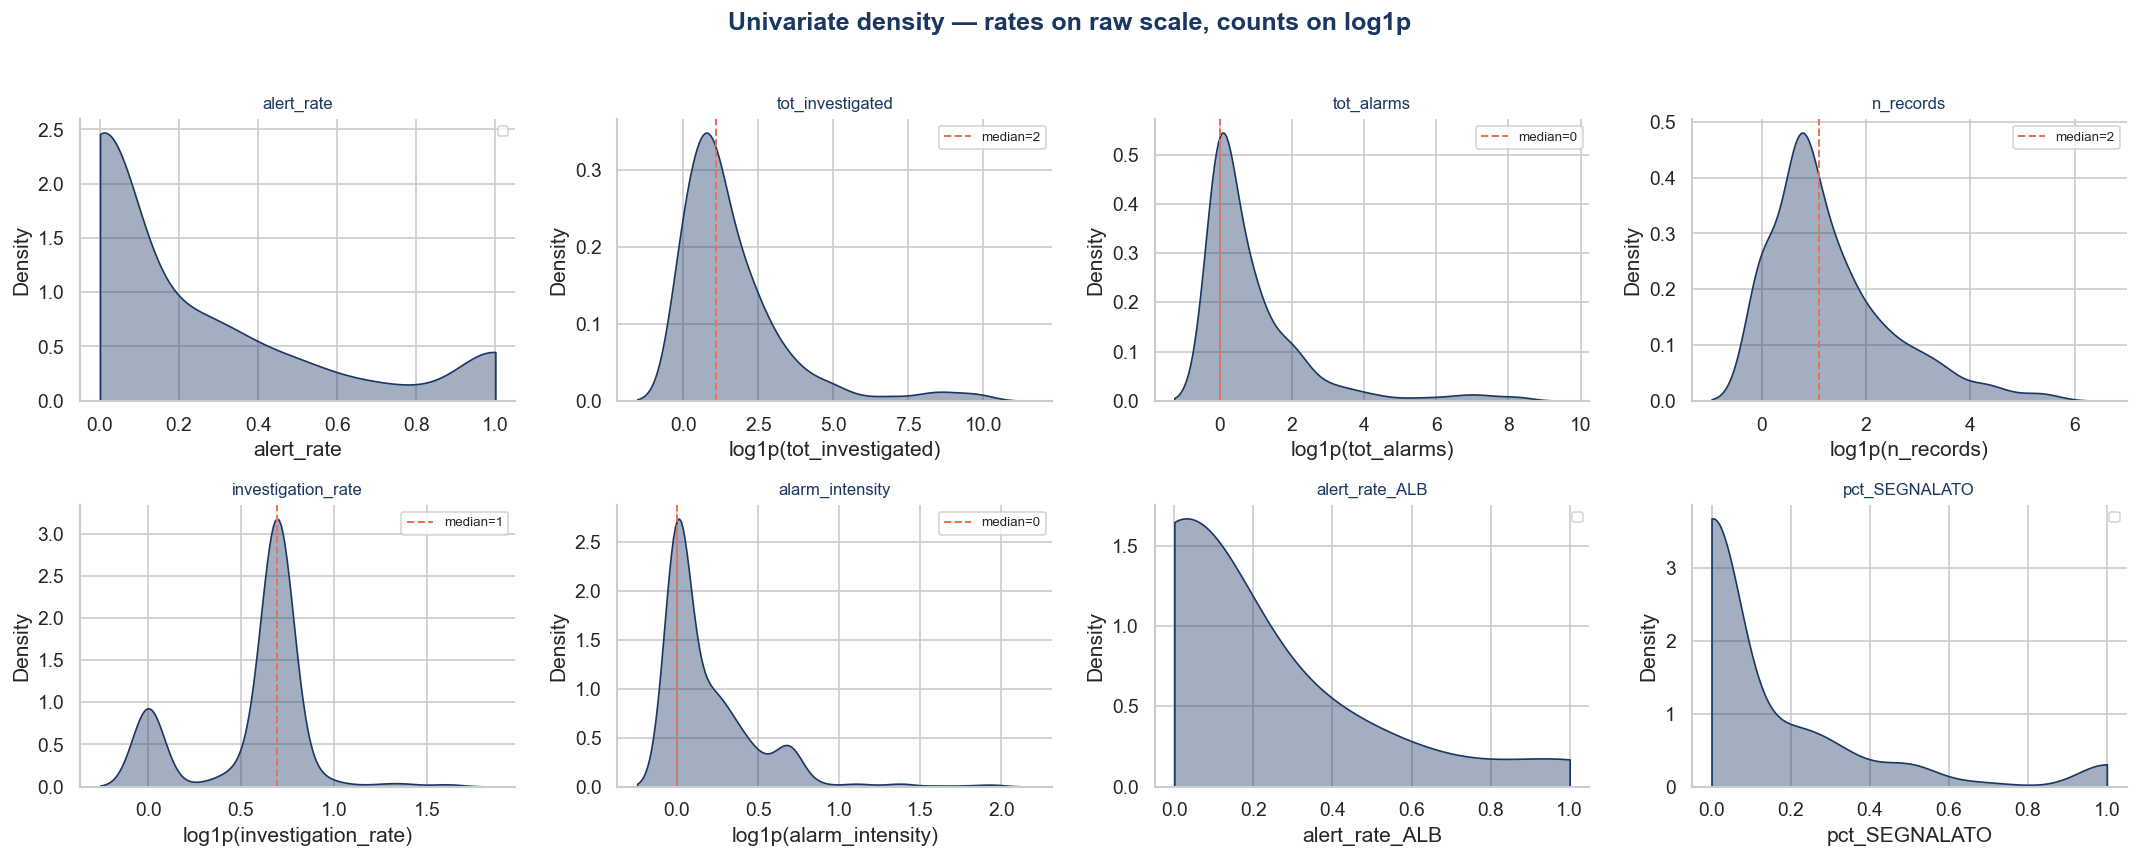

In [99]:
plot_feats = ['alert_rate', 'tot_investigated', 'tot_alarms', 'tot_entries',
              'n_records', 'investigation_rate', 'alarm_intensity'] + \
             [f'alert_rate_{top_nat[0]}', f'pct_{top_co[0]}']
plot_feats = [c for c in plot_feats if c in df_route.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.flatten(), plot_feats):
    s = df_route[c].dropna()
    is_rate = c.startswith(('alert_rate', 'pct_'))
    if is_rate:
        sns.kdeplot(s, ax=ax, color=NAVY, fill=True, alpha=0.4, clip=(0, 1))
    else:
        sns.kdeplot(np.log1p(s), ax=ax, color=NAVY, fill=True, alpha=0.4)
        ax.set_xlabel(f'log1p({c})')
        ax.axvline(np.log1p(s.median()), color=CORAL, ls='--', lw=1.2,
                   label=f'median={int(s.median())}')
    ax.set_title(c, color=NAVY, fontsize=10)
    ax.legend(fontsize=8, loc='upper right'); sns.despine(ax=ax)
plt.suptitle('Univariate density — rates on raw scale, counts on log1p',
             fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout(); plt.show()

## 4. Bivariate analysis

Single scatter answering the central question of the project: do high alert-rate routes also have high volumes, or are they low-volume artifacts? Bubble size encodes absolute alarms; the median rate line is the cross-sectional reference.

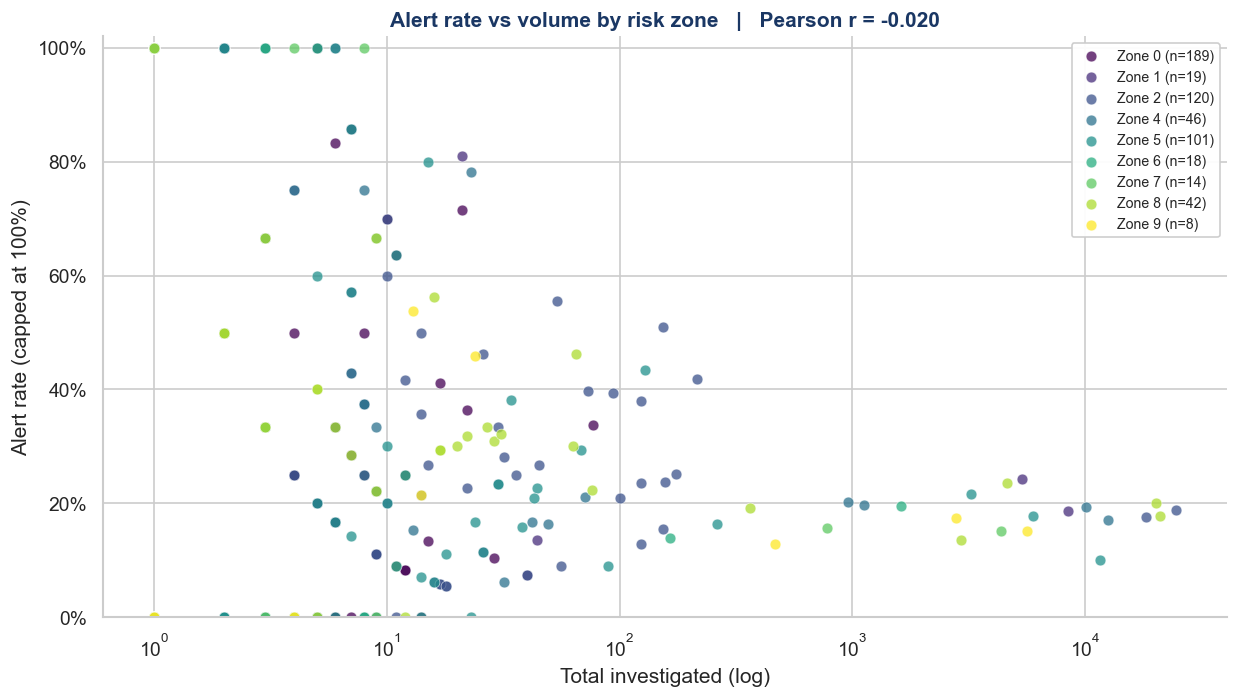

In [100]:
median_rate = df_route['alert_rate'].median()

# Sequential colormap on ZONE — natural ordering 0→9
zones_sorted = sorted([z for z in df_route['ZONE'].dropna().unique()])
cmap = plt.cm.viridis
zone_colors = {z: cmap(i / max(len(zones_sorted)-1, 1)) for i, z in enumerate(zones_sorted)}

pearson_r = df_route['tot_investigated'].corr(df_route['alert_rate'])

fig, ax = plt.subplots(figsize=(10.5, 6))
for z in zones_sorted:
    sub = df_route[df_route['ZONE'] == z]
    ax.scatter(sub['tot_investigated'].clip(lower=1), sub['alert_rate'],
               c=[zone_colors[z]], s=42, alpha=0.75,
               edgecolor='white', linewidth=0.4,
               label=f'Zone {int(z)} (n={len(sub)})')
no_zone = df_route[df_route['ZONE'].isna()]
if len(no_zone) > 0:
    ax.scatter(no_zone['tot_investigated'].clip(lower=1), no_zone['alert_rate'],
               c='lightgrey', s=25, alpha=0.5, marker='x',
               label=f'No zone (n={len(no_zone)})')

ax.set_xscale('log'); ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('Total investigated (log)'); ax.set_ylabel('Alert rate (capped at 100%)')
ax.set_title(f'Alert rate vs volume by risk zone   |   Pearson r = {pearson_r:+.3f}',
             fontweight='bold', color=NAVY)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.95, ncol=1)
sns.despine(); plt.tight_layout(); plt.show()

## 5. Multivariate analysis

Lower-triangular Pearson matrix on the engineered numeric features; flags multi-collinearity that would dominate distance-based detectors (LOF, DBSCAN) if left unaddressed.

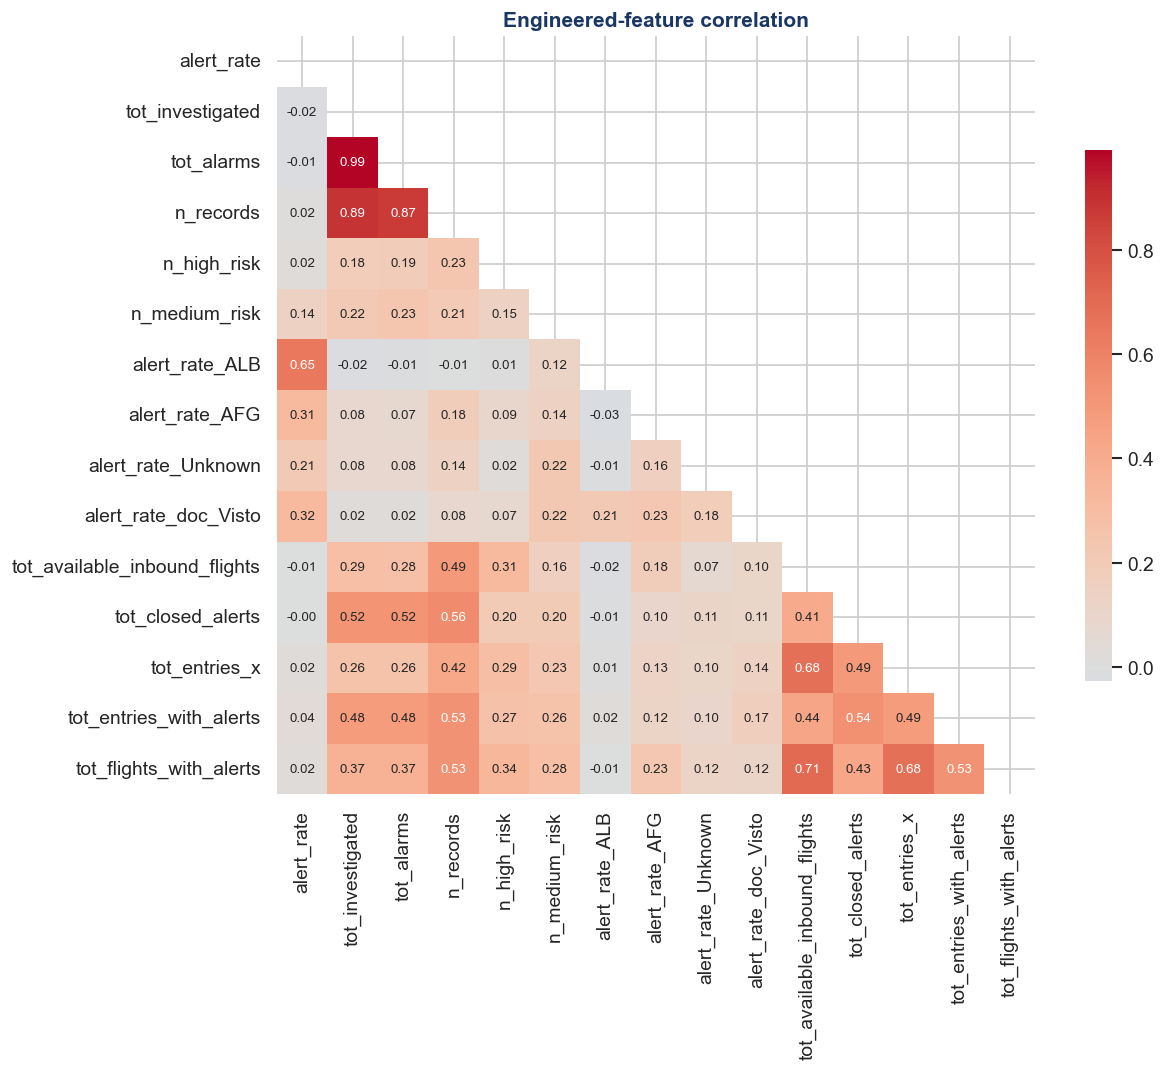

In [101]:
mv_cols = (['alert_rate','tot_investigated','tot_alarms','tot_entries','n_records',
            'n_high_risk','n_medium_risk']
           + [c for c in df_route.columns if c.startswith('alert_rate_')][:4]
           + [c for c in df_route.columns if c.startswith('tot_') 
              and c not in ('tot_entries','tot_investigated','tot_alarms')][:5])
mv_cols = [c for c in mv_cols if c in df_route.columns]
corr = df_route[mv_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
plt.title('Engineered-feature correlation', fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show()

### 5.2 Pair plot — selected features

Four features picked for semantic distance: a global rate, a volume, a risk-weighted count, a segmented rate (top nationality), an outcome proportion. Diagonal = KDE marginal; off-diagonal = pairwise scatter. Reveals non-linear relationships and clusters that the heatmap collapses into a single number.

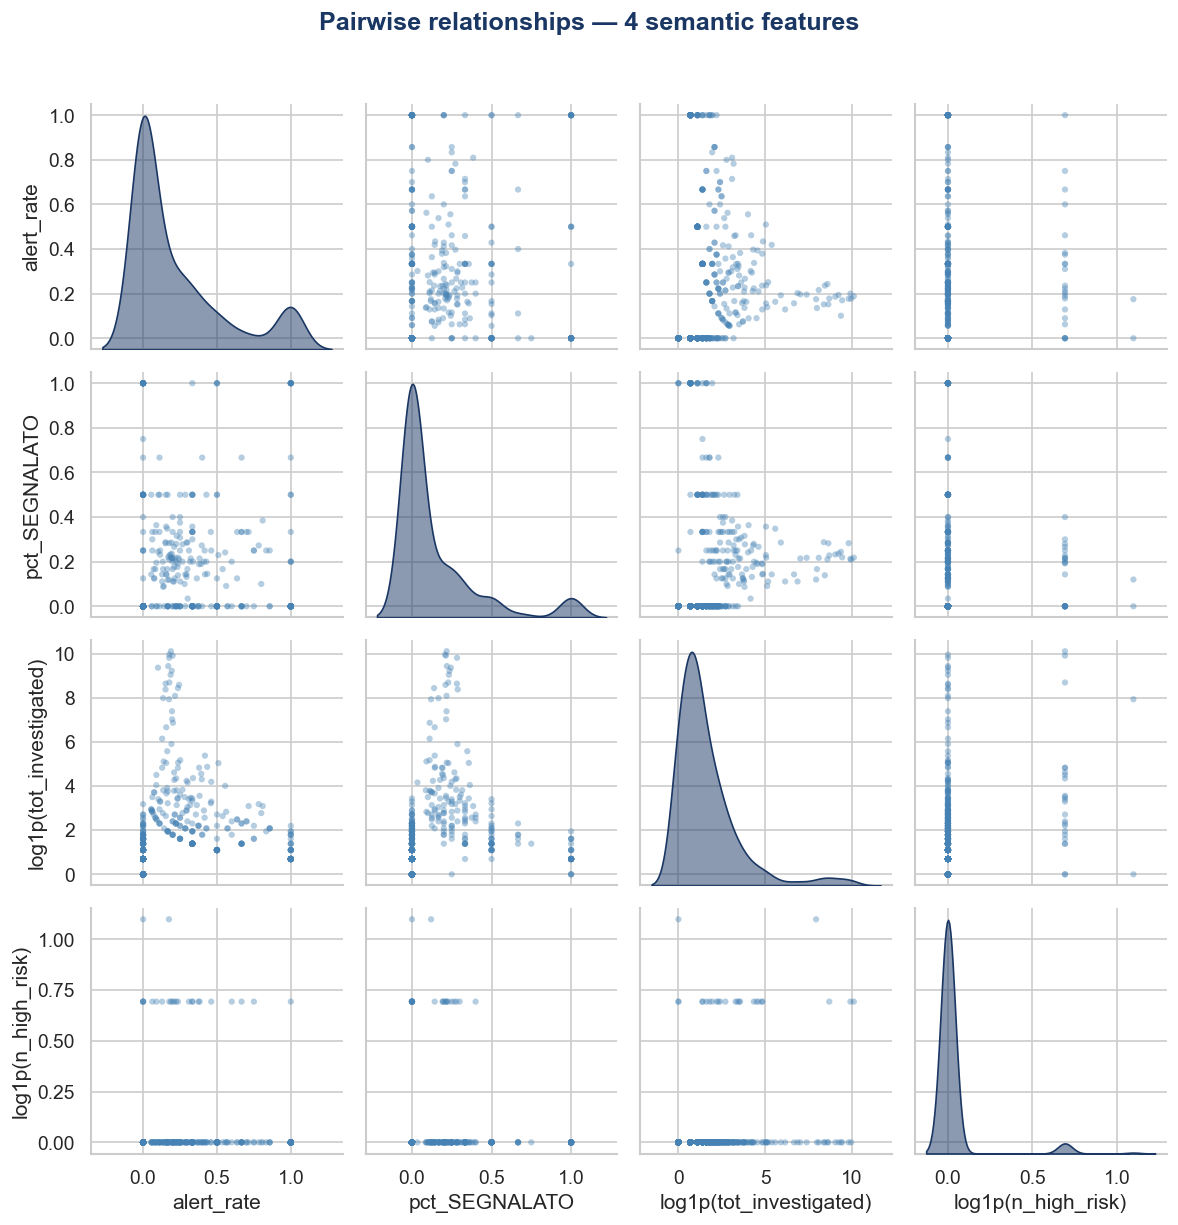

(None, None)

In [102]:
pair_feats = ['alert_rate', 'tot_investigated', 'n_high_risk', f'pct_{top_co[0]}']
pair_feats = [c for c in pair_feats if c in df_route.columns]

sample = df_route[pair_feats].copy()
for c in ['tot_investigated', 'n_high_risk']:
    if c in sample.columns:
        sample[f'log1p({c})'] = np.log1p(sample[c])
        sample = sample.drop(columns=c)
if len(sample) > 800:
    sample = sample.sample(800, random_state=RANDOM_STATE)

g = sns.pairplot(sample, diag_kind='kde',
                 plot_kws={'alpha': 0.4, 'color': STEEL, 's': 14, 'edgecolor': 'none'},
                 diag_kws={'color': NAVY, 'fill': True, 'alpha': 0.5})
g.figure.suptitle('Pairwise relationships — 4 semantic features',
                  fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout(), plt.show()

## 6. Outlier analysis — robust modified Z-score

Standard 1.5·IQR is unsuited to right-skewed count data: it flags an entire shoulder of the distribution as anomalous. We adopt the modified Z-score on the log1p-transformed values: z_mod = 0.6745 · (x − median) / MAD, with MAD the median absolute deviation. The transformation tames the skew; MAD is robust to the same outliers we are trying to flag (unlike the standard deviation, which they would inflate). Threshold |z_mod| > 3.5 follows Iglewicz & Hoaglin (1993). The result is a descriptive flag — these rows are not removed; they remain the signal the detector must learn.

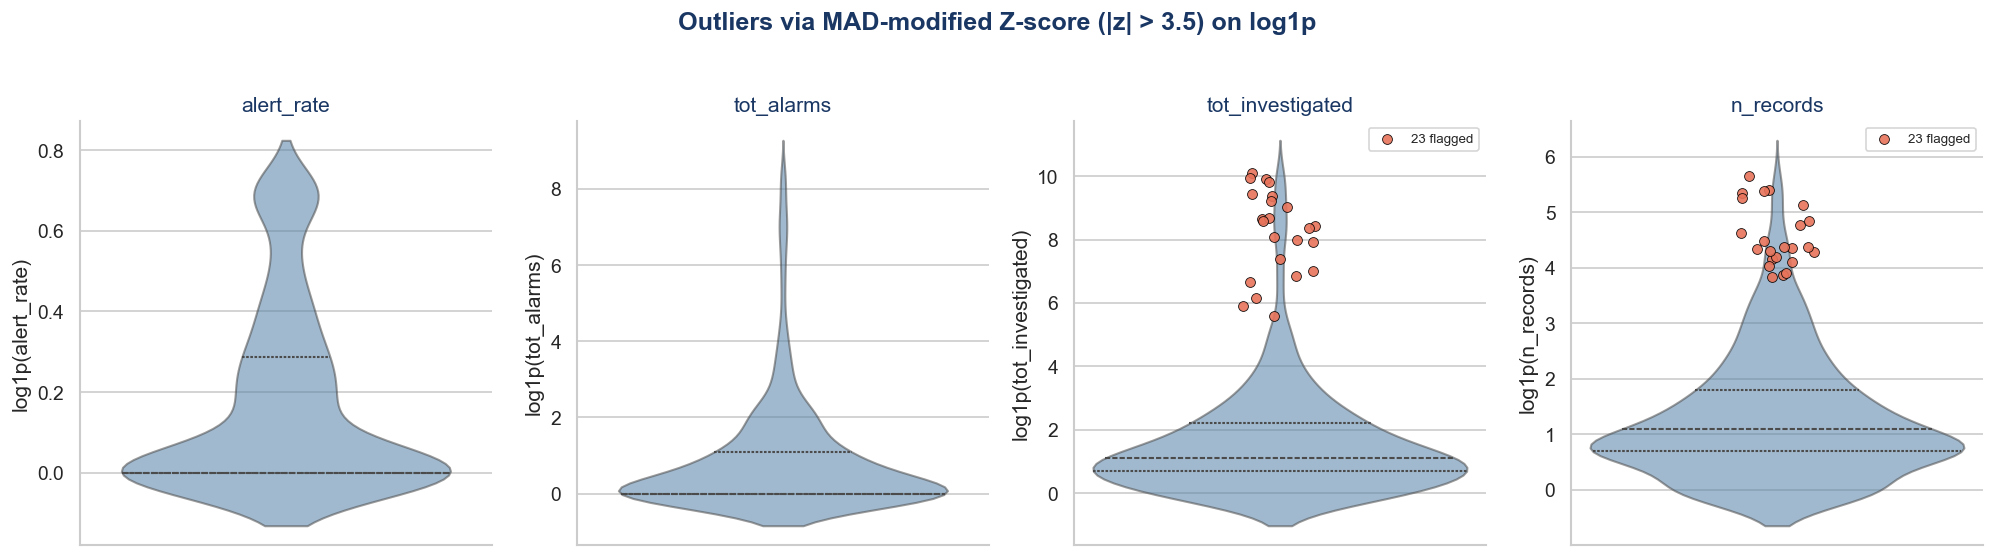

,median_raw,MAD_log,n_flagged,%
col,,,,
alert_rate,0.00,0.00,0,0.00
tot_alarms,0.00,0.00,0,0.00
tot_investigated,2.00,0.85,23,4.13
n_records,2.00,0.51,23,4.13


In [103]:
def mad_modified_zscore(series, threshold=3.5):
    """MAD-based modified Z-score on log1p-transformed series.
    Robust to skewness and to the outliers themselves."""
    s = np.log1p(series.dropna())
    med = s.median()
    mad = np.median(np.abs(s - med))
    if mad == 0:
        return pd.Series(False, index=series.index), pd.Series(np.nan, index=series.index)
    mod_z = 0.6745 * (s - med) / mad
    flagged = pd.Series(False, index=series.index)
    flagged.loc[mod_z.index] = np.abs(mod_z) > threshold
    z_full = pd.Series(np.nan, index=series.index)
    z_full.loc[mod_z.index] = mod_z.values
    return flagged, z_full

outlier_cols = ['alert_rate', 'tot_alarms', 'tot_investigated', 'n_records']
flags, zscores = {}, {}
for c in outlier_cols:
    flags[c], zscores[c] = mad_modified_zscore(df_route[c])

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(4.2*len(outlier_cols), 4.5))
for ax, c in zip(axes, outlier_cols):
    s_log = np.log1p(df_route[c].dropna())
    sns.violinplot(y=s_log, ax=ax, color=STEEL, inner='quartile', alpha=0.55)
    flagged_idx = flags[c][flags[c]].index
    if len(flagged_idx) > 0:
        flagged_y = np.log1p(df_route.loc[flagged_idx, c])
        jitter = np.random.uniform(-0.08, 0.08, len(flagged_y))
        ax.scatter(jitter, flagged_y, color=CORAL, s=35,
                   edgecolor='black', linewidths=0.5, zorder=3, alpha=0.9,
                   label=f'{flags[c].sum()} flagged')
        ax.legend(fontsize=8, loc='upper right')
    ax.set_title(c, color=NAVY); ax.set_ylabel(f'log1p({c})')
    sns.despine(ax=ax)
plt.suptitle('Outliers via MAD-modified Z-score (|z| > 3.5) on log1p',
             fontweight='bold', color=NAVY, y=1.03)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    'col': outlier_cols,
    'median_raw': [df_route[c].median() for c in outlier_cols],
    'MAD_log':    [np.median(np.abs(np.log1p(df_route[c].dropna())
                   - np.log1p(df_route[c].dropna()).median()))
                   for c in outlier_cols],
    'n_flagged':  [int(flags[c].sum()) for c in outlier_cols],
    '%':          [round(flags[c].sum() / len(df_route) * 100, 2) for c in outlier_cols],
}).set_index('col')
display(summary)

## 7. Feature engineering

The four detectors operate on a numeric matrix. We need three things from it:   
(i) a deterministic, auto-adapting feature selection so the pipeline does not break when the upstream segmentation changes;   
(ii) a transform that compresses the right-skew typical of count features without distorting bounded rates;   
(iii) a scaling that puts every feature on the same dispersion, so distance-based detectors weigh them comparably.

### 7.1 Feature selection — by prefix, deterministic
The columns are picked by **prefix match** (`tot_*`, `alert_rate*`, `pct_*`, `n_*risk`) rather than hardcoded names.   
This means: when the §2.8
auto-detection finds a different set of top nationalities or document
types, the feature list adjusts automatically — no silent drift.

In [104]:
count_features = [c for c in df_route.columns if c.startswith('tot_')]
rate_features  = [c for c in df_route.columns
                  if c.startswith('alert_rate') or c.startswith('pct_')]
risk_features  = [c for c in ['n_high_risk', 'n_medium_risk'] if c in df_route.columns]
feature_cols = count_features + rate_features + risk_features + ['alarm_intensity', 'investigation_rate']
feature_cols = [c for c in feature_cols if c in df_route.columns]
print(f'Total features : {len(feature_cols)}')
print(f'  Counts ({len(count_features):>2}) : {count_features[:5]} ...')
print(f'  Rates  ({len(rate_features):>2}) : {rate_features[:5]} ...')
print(f'  Risk   ({len(risk_features):>2}) : {risk_features}')

Total features : 34
  Counts (17) : ['tot_available_inbound_flights', 'tot_closed_alerts', 'tot_entries_x', 'tot_entries_with_alerts', 'tot_flights_with_alerts'] ...
  Rates  (13) : ['alert_rate', 'alert_rate_ALB', 'pct_nat_ALB', 'alert_rate_AFG', 'pct_nat_AFG'] ...
  Risk   ( 2) : ['n_high_risk', 'n_medium_risk']


### 7.2 log1p compression of count skew
Count features (`tot_*`, `n_*risk`) are right-skewed and zero-inflated:  
peak at 0, long tail to thousands. On linear scale the detectors would mostly rank by raw magnitude — losing the relative-deviation signal.  

`log1p(x) = log(1 + x)` solves both: handles zeros without diverging (unlike `log`), and compresses the tail.   
A route with 10 000 alarms ends upat ≈9.2; one with 100 alarms at ≈4.6 — distance shrinks from 9 900 to 4.6, the right scale for distance-based methods (LOF, DBSCAN).  

Applied uniformly: rate features are bounded in [0, 1], so `log1p` is nearly the identity on them (`log1p(0.5) ≈ 0.41`) — no harm done.   
We verify the skewness drop below.

In [105]:
from scipy.stats import skew

X = df_route[feature_cols].fillna(0).astype(float)
X_log = np.log1p(X.values)

skew_before = pd.Series(skew(X.values), index=feature_cols).abs()
skew_after  = pd.Series(skew(X_log),     index=feature_cols).abs()
print(f"|Skewness| mean   : {skew_before.mean():.2f}  ->  {skew_after.mean():.2f}")
print(f"|Skewness| max    : {skew_before.max():.2f}  ->  {skew_after.max():.2f}")
print(f"Features with |skew|>2 (severely skewed):")
print(f"   before log1p: {(skew_before > 2).sum()} -> {len(feature_cols)}")
print(f"   after  log1p: {(skew_after  > 2).sum()} -> {len(feature_cols)}")

|Skewness| mean   : 5.41  ->  3.08
|Skewness| max    : 23.50  ->  16.10
Features with |skew|>2 (severely skewed):
   before log1p: 30 -> 34
   after  log1p: 17 -> 34


### 7.3 Standardisation — the cross-sectional baseline
After scaling, every value is *"how many standard deviations from the population mean"* — a z-score relative to the cross-sectional baseline.  
This is exactly the reference distribution the brief calls for, given that the 2-month window does not support a temporal baseline.  

This step is what allows LOF and DBSCAN to weigh all features comparably:   
without it, `tot_investigated` (range 0–10⁴ even after log1p) would dominate `alert_rate` (range 0–1) by orders of magnitude in any Euclidean distance, and the rate signal would be invisible to them.  

Isolation Forest is scale-invariant — its splits use one feature at a time — but we feed it the same matrix for code consistency.

In [106]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log),
                        columns=feature_cols, index=X.index)

print(f'X_scaled shape    : {X_scaled.shape}')
print(f'Mean over matrix  : {X_scaled.values.mean():.6f}  (target ≈ 0)')
print(f'Std  over matrix  : {X_scaled.values.std():.6f}   (target ≈ 1)')
print(f'\nPer-feature std (first 5):')
print(X_scaled.std().head().round(3).to_string())

X_scaled shape    : (557, 34)
Mean over matrix  : -0.000000  (target ≈ 0)
Std  over matrix  : 1.000000   (target ≈ 1)

Per-feature std (first 5):
tot_available_inbound_flights   1.00
tot_closed_alerts               1.00
tot_entries_x                   1.00
tot_entries_with_alerts         1.00
tot_flights_with_alerts         1.00


## 8. Anomaly detection — four-detector ensemble

Four independent biases: random isolation (IF), local density (LOF), density connectivity (DBSCAN), parametric tail (Z-score). A route reaches consensus with ≥ 2/4 votes — stricter than a single detector, less brittle than full unanimity.

In [107]:
flags = fit_detectors(X_scaled, contamination=CONTAMINATION,
                      random_state=RANDOM_STATE)

# attach flags + scores to df_route
df_route = pd.concat([df_route.reset_index(drop=True),
                      flags.reset_index(drop=True)], axis=1)

det_cols = ["if_anomaly", "lof_anomaly", "dbscan_anomaly", "z_anomaly"]
print("Per-detector flags:")
print(df_route[det_cols].sum().to_string())
print(f"\nVote distribution:\n{df_route['anomaly_votes'].value_counts().sort_index().to_string()}")
print(f"\nDBSCAN: min_samples={flags.attrs.get('dbscan_min_samples')}, "
      f"eps={flags.attrs.get('dbscan_eps'):.3f}, "
      f"noise={flags.attrs.get('dbscan_noise_pct'):.1%}")
print(f"Consensus (≥2/4): {df_route['anomaly_consensus'].sum()} routes")

Per-detector flags:
if_anomaly         28
lof_anomaly        28
dbscan_anomaly     16
z_anomaly         215

Vote distribution:
anomaly_votes
0    322
1    193
2     33
3      8
4      1

DBSCAN: min_samples=8, eps=7.936, noise=2.9%
Consensus (≥2/4): 42 routes


### Ensemble vote distribution — PCA projection

To visualise the consensus anomaly structure, the scaled feature matrix is
projected onto two principal components. Each point is coloured by its vote
count (0–4 detectors agreeing). Points with more votes cluster away from the
dense normal cloud, confirming that the ensemble agreement is geometrically
meaningful in feature space and not an artefact of a single detector's bias.

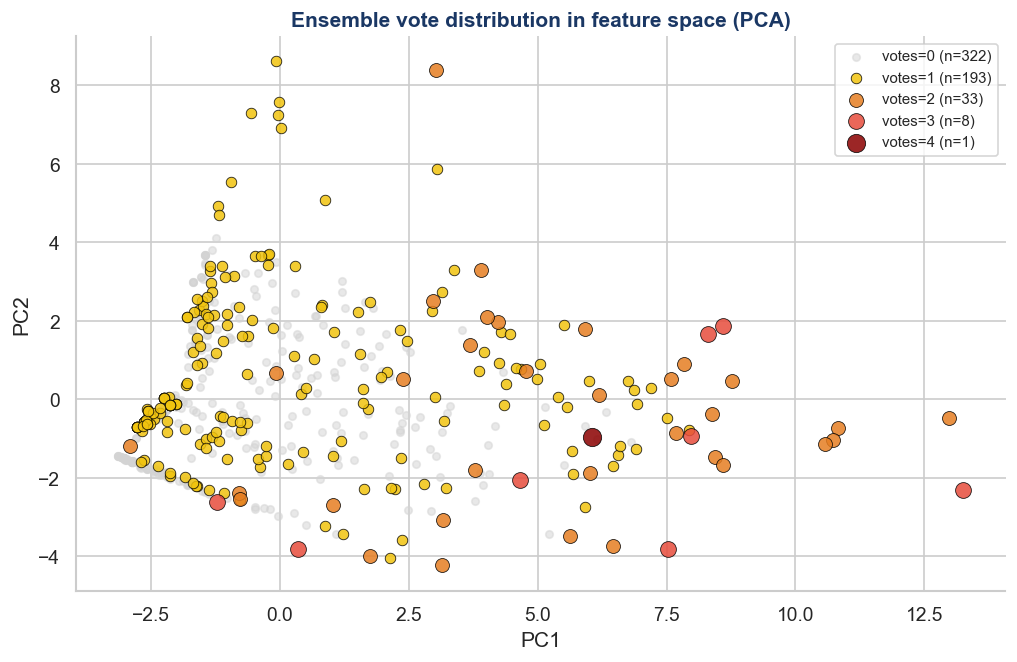

In [108]:
from sklearn.decomposition import PCA
pc = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(pc[df_route['anomaly_votes']==0, 0], pc[df_route['anomaly_votes']==0, 1],
            c='lightgrey', s=20, alpha=0.5, label=f"votes=0 (n={(df_route['anomaly_votes']==0).sum()})")
for v, color, size in [(1,'#F1C40F',40), (2,'#E67E22',70), (3,'#E74C3C',90), (4,'#8B0000',120)]:
    m = df_route['anomaly_votes'] == v
    if m.any():
        plt.scatter(pc[m, 0], pc[m, 1], c=color, s=size, alpha=0.85,
                    edgecolor='black', linewidths=0.5, label=f'votes={v} (n={m.sum()})')
plt.xlabel(f'PC1'); plt.ylabel(f'PC2')
plt.title('Ensemble vote distribution in feature space (PCA)', fontweight='bold', color=NAVY)
plt.legend(loc='best', fontsize=9); sns.despine(); plt.show()

## 8.1 Sensitivity analysis on contamination

The contamination parameter encodes the prior on anomaly rate for IF and LOF.   
We chose 0.05 to match the order of magnitude of the Whitehall brief examples; this section makes the choice empirically defensible by sweeping contamination ∈ {0.03, 0.05, 0.07, 0.10} and tracking how per-detector flags and consensus counts evolve.   
DBSCAN and Z-score have their own independent thresholds and stay static across the sweep — the consensus moves only because of the IF/LOF re-fit.

,contamination,IF,LOF,IF∩LOF,DBSCAN,Z,consensus_>=2,consensus_>=3
0,0.03,17,17,1,16,215,32,7
1,0.05,28,28,1,16,215,42,9
2,0.07,39,39,4,16,215,48,14
3,0.10,56,56,6,16,215,65,16


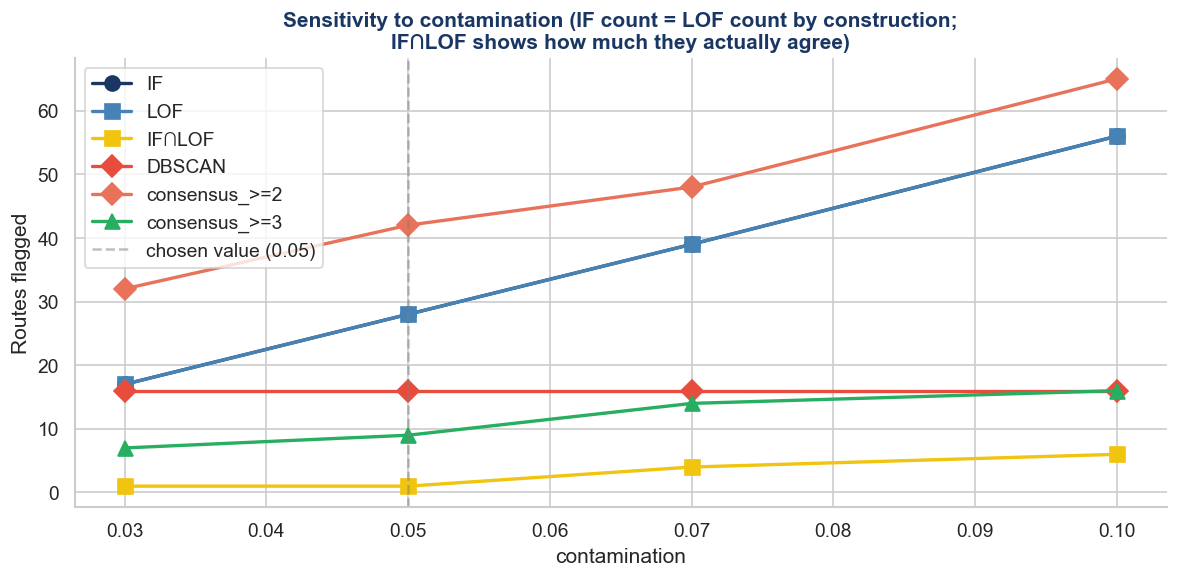


Delta consensus_>=2 across the sweep: 33 routes (32 -> 65)


In [109]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

contamination_grid = [0.03, 0.05, 0.07, 0.10]
db_static = df_route['dbscan_anomaly'].values
z_static  = df_route['z_anomaly'].values

sens_rows = []
for c in contamination_grid:
    iso_c = IsolationForest(n_estimators=200, contamination=c,
                            random_state=RANDOM_STATE).fit(X_scaled)
    lof_c = LocalOutlierFactor(n_neighbors=20, contamination=c)
    if_flag  = (iso_c.predict(X_scaled) == -1).astype(int)
    lof_flag = (lof_c.fit_predict(X_scaled) == -1).astype(int)
    if_set  = set(np.where(if_flag  == 1)[0])
    lof_set = set(np.where(lof_flag == 1)[0])
    if_lof_intersection = len(if_set & lof_set)
    votes = if_flag + lof_flag + db_static + z_static
    sens_rows.append({
        'contamination': c,
        'IF':  int(if_flag.sum()),
        'LOF': int(lof_flag.sum()),
        'IF∩LOF': if_lof_intersection,
        'DBSCAN': int(db_static.sum()), 'Z': int(z_static.sum()),
        'consensus_>=2': int((votes >= 2).sum()),
        'consensus_>=3': int((votes >= 3).sum()),
    })

sens_df = pd.DataFrame(sens_rows)
display(sens_df)

fig, ax = plt.subplots(figsize=(10, 5))
for col, color, marker in [('IF', NAVY, 'o'), ('LOF', STEEL, 's'),
                           ('IF∩LOF', GOLD, 's'),
                            ('DBSCAN', RED, 'D'),
                           ('consensus_>=2', CORAL, 'D'),
                           ('consensus_>=3', GREEN, '^')]:
    ax.plot(sens_df['contamination'], sens_df[col],
            color=color, marker=marker, linewidth=2, markersize=9, label=col)
ax.axvline(0.05, color='gray', ls='--', alpha=0.5, label='chosen value (0.05)')
ax.set_xlabel('contamination'); ax.set_ylabel('Routes flagged')
ax.set_title('Sensitivity to contamination (IF count = LOF count by construction;\n'
             'IF∩LOF shows how much they actually agree)',
             fontweight='bold', color=NAVY)
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

print(f"\nDelta consensus_>=2 across the sweep: "
      f"{sens_df['consensus_>=2'].max() - sens_df['consensus_>=2'].min()} routes "
      f"({sens_df['consensus_>=2'].min()} -> {sens_df['consensus_>=2'].max()})")

## 9. Post-processing — operational ranking

Three layers on the consensus subset: (i) risk_level from rate × volume × votes, (ii) Wilson 95 % CI on the alert rate (handles small-volume routes), (iii) priority_score = 0.60·rate_norm + 0.40·log(absolute_alarms)_norm. Output stratified into a transit anomaly report.

In [110]:
df_post, df_clean = apply_post_processing(df_route, drop_disqualified=True)

print(f"Consensus routes (df_post): {len(df_post)}")
print(f"After QA filter (df_clean): {len(df_clean)}")
print(f"Excluded by quality_note  : {len(df_post) - len(df_clean)}")
print(f"\nRisk distribution in df_clean:")
print(df_clean['risk_level'].value_counts()
      .reindex(['CRITICAL','HIGH','MEDIUM','LOW']).fillna(0).astype(int).to_string())

display(df_clean[['rank','route','risk_level','alert_rate','tot_investigated',
                  'ci95_str','ci_tightness','priority_score','quality_note']]
        .head(20))

Consensus routes (df_post): 42
After QA filter (df_clean): 33
Excluded by quality_note  : 9

Risk distribution in df_clean:
risk_level
CRITICAL     1
HIGH        16
MEDIUM      12
LOW          4


,rank,route,risk_level,alert_rate,tot_investigated,ci95_str,ci_tightness,priority_score,quality_note
0,1,TIA→BGY,HIGH,0.19,24403.00,"[18.4%, 19.3%]",0.99,0.51,ok
1,2,TIA→BLQ,MEDIUM,0.20,20029.00,"[19.5%, 20.6%]",0.99,0.51,ok
2,3,TIA→PSA,MEDIUM,0.18,20929.00,"[17.2%, 18.3%]",0.99,0.49,ok
3,4,TIA→MXP,MEDIUM,0.18,18147.00,"[17.1%, 18.3%]",0.99,0.48,ok
4,5,IST→CTA,HIGH,1.00,8.00,"[67.6%, 100.0%]",0.68,0.48,ok
5,6,TIA→AOI,MEDIUM,0.24,4598.00,"[22.4%, 24.8%]",0.98,0.46,ok
6,7,TIA→TSF,LOW,0.17,12469.00,"[16.4%, 17.7%]",0.99,0.46,ok
7,8,SAW→BGY,HIGH,0.51,153.00,"[43.1%, 58.8%]",0.84,0.43,ok
8,9,DOH→MXP,HIGH,1.00,6.00,"[61.0%, 100.0%]",0.61,0.42,ok
9,10,IST→VCE,HIGH,0.78,23.00,"[58.1%, 90.3%]",0.68,0.41,ok


### 9.1 Priority ranking — top routes by risk score

Consensus anomalies are ranked by a composite priority score:
`0.60 × alert_rate_norm + 0.40 × log(absolute_alarms)_norm`, weighted by a
Wilson 95% CI confidence factor so that high rates observed on very small
samples are correctly downweighted. Routes flagged by a data quality check
(`incomplete data` or `likely false positive`) are excluded from the visual
but reported separately. Each bar shows the score, risk level, confidence
interval, and detector vote count.

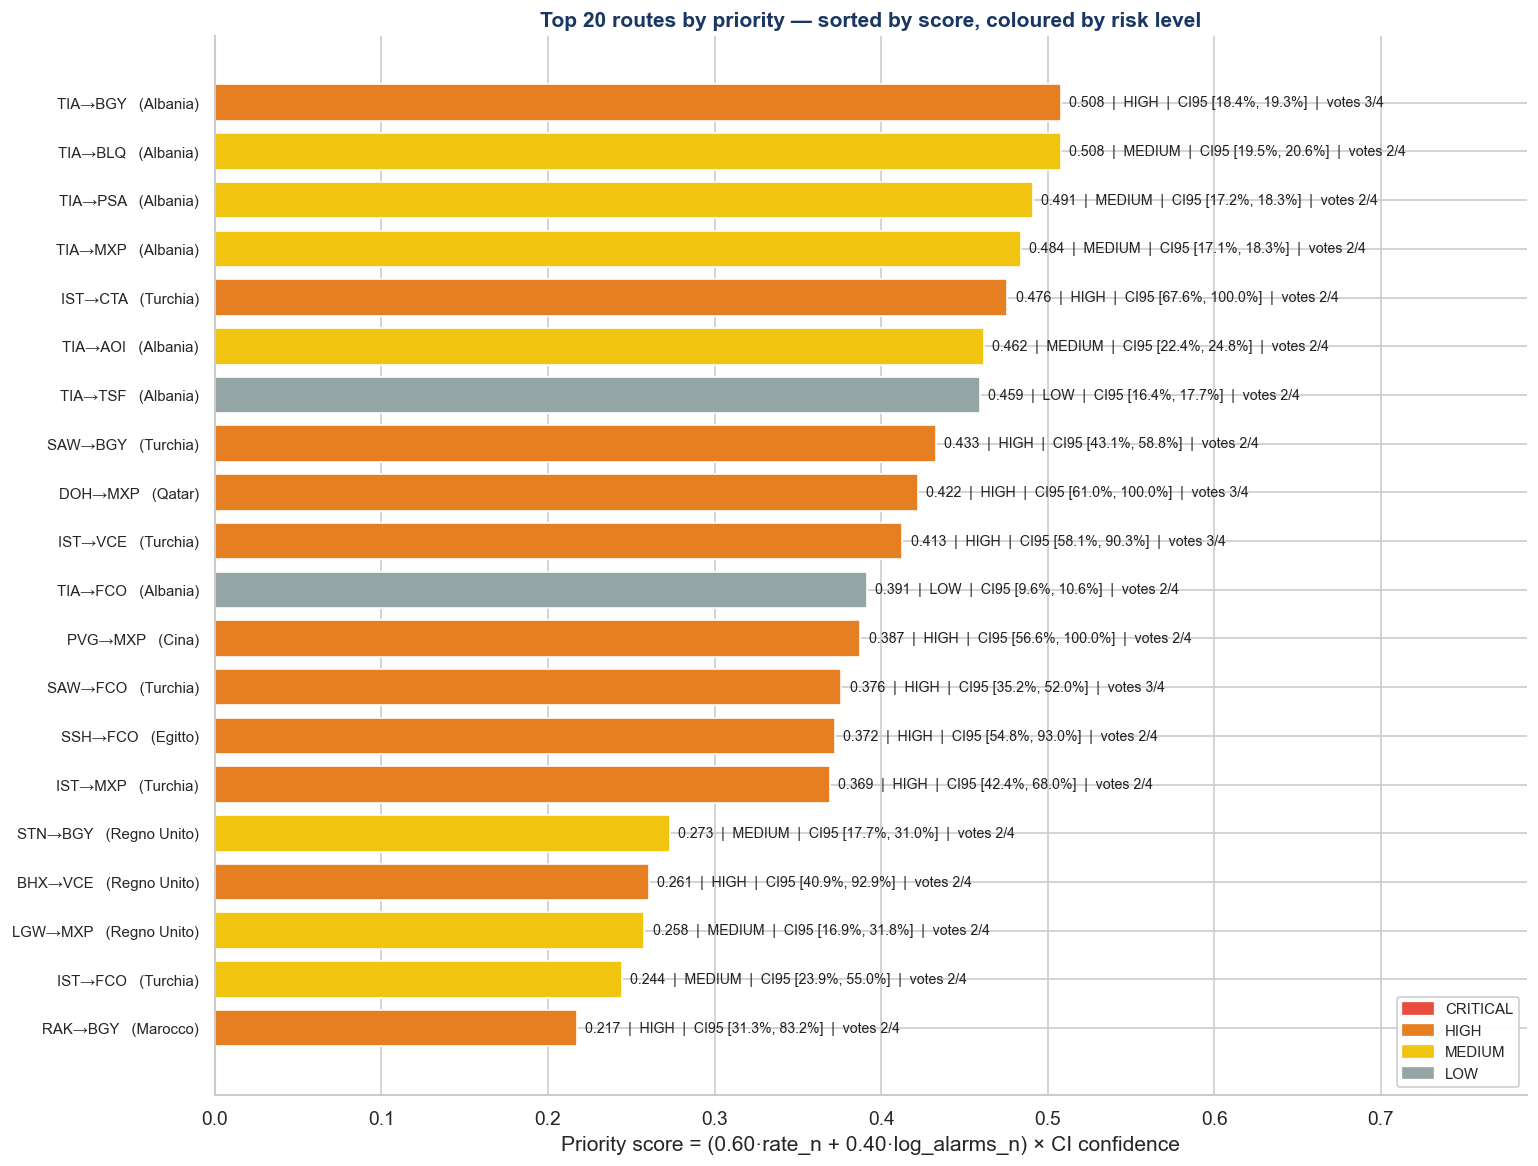

In [111]:
color_map = {'CRITICAL':'#E74C3C', 'HIGH':'#E67E22',
             'MEDIUM':'#F1C40F',   'LOW':'#95A5A6'}

N_SHOW = min(20, len(df_clean))
df_plot = df_clean.head(N_SHOW).iloc[::-1]
labels = (df_plot['route'] + '   ('
          + df_plot['DEPARTURE_COUNTRY'].fillna('n/a').astype(str) + ')')

fig, ax = plt.subplots(figsize=(13, 0.42 * N_SHOW + 1.5))
ax.barh(range(N_SHOW), df_plot['priority_score'],
        color=[color_map[l] for l in df_plot['risk_level']],
        edgecolor='white', height=0.75)

for i, (sc, ci, vt, lvl, qn) in enumerate(zip(df_plot['priority_score'],
                                               df_plot['ci95_str'],
                                               df_plot['anomaly_votes'],
                                               df_plot['risk_level'],
                                               df_plot['quality_note'])):
    suffix = '  ⚠' if qn != 'ok' else ''
    ax.text(sc + 0.005, i,
            f'{sc:.3f}  |  {lvl}  |  CI95 {ci}  |  votes {int(vt)}/4{suffix}',
            va='center', fontsize=8.5, color='#222')

ax.set_yticks(range(N_SHOW))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Priority score = (0.60·rate_n + 0.40·log_alarms_n) × CI confidence')
ax.set_title(f'Top {N_SHOW} routes by priority — sorted by score, coloured by risk level',
             fontweight='bold', color=NAVY)
ax.set_xlim(0, max(df_plot['priority_score'].max() * 1.55, 0.1))

from matplotlib.patches import Patch
patches = [Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9, framealpha=0.95)
sns.despine(); plt.tight_layout(); plt.show()

### 9.2 Final anomaly report

Full pipeline summary: routes analysed, detector coverage at each threshold,
and the final set of reliable confirmed anomalies broken down by risk level.
Routes excluded by the data quality filter are listed separately with their
exclusion reason. This output is the operational deliverable of the classical
pipeline, the equivalent of what the Report Agent produces in the multi-agent
notebook.

In [112]:
print(f"""
  Routes analyzed       : {len(df_route)}
  ≥1 detector flagged   : {(df_route['anomaly_votes']>=1).sum()}
  Consensus (≥2/4)      : {len(df_post)}
  Reliable in report    : {len(df_clean)}
  Excluded (data QA)    : {len(df_post) - len(df_clean)}

  CRITICAL : {(df_post['risk_level']=='CRITICAL').sum()}
  HIGH     : {(df_post['risk_level']=='HIGH').sum()}
  MEDIUM   : {(df_post['risk_level']=='MEDIUM').sum()}
  LOW      : {(df_post['risk_level']=='LOW').sum()}

  Priority score: 0.60·alert_rate_norm + 0.40·log(abs_alarms)_norm
""")

excluded = df_post[~df_post.index.isin(df_clean.index)]
if len(excluded) > 0:
    print(f"\n{'='*70}\nEXCLUDED ROUTES — {len(excluded)} (data QA)\n{'='*70}")
    for _, r in excluded.iterrows():
        print(f"  {r['route']}  [{r['risk_level']}]  →  {r['quality_note']}")


  Routes analyzed       : 557
  ≥1 detector flagged   : 235
  Consensus (≥2/4)      : 42
  Reliable in report    : 33
  Excluded (data QA)    : 9

  CRITICAL : 1
  HIGH     : 18
  MEDIUM   : 12
  LOW      : 11

  Priority score: 0.60·alert_rate_norm + 0.40·log(abs_alarms)_norm


EXCLUDED ROUTES — 9 (data QA)
  WNZ→FCO  [LOW]  →  likely false positive — flagged on non-rate features
  TUN→PMO  [HIGH]  →  likely false positive — flagged on non-rate features
  TPE→MXP  [LOW]  →  likely false positive — flagged on non-rate features
  PEK→FCO  [LOW]  →  likely false positive — flagged on non-rate features
  CLE→FLR  [LOW]  →  likely false positive — flagged on non-rate features
  DSS→MXP  [LOW]  →  likely false positive — flagged on non-rate features
  GRU→FCO  [LOW]  →  likely false positive — flagged on non-rate features
  SZX→FCO  [HIGH]  →  likely false positive — flagged on non-rate features
  WNZ→MXP  [LOW]  →  likely false positive — flagged on non-rate features


## 10. Conclusions and next steps

### 10.1 Summary
End-to-end classical pipeline at route level: cleaning → route aggregation with
pivot-on-OCCURRENCES + segmented alert rates → 4-detector ensemble (Isolation
Forest, LOF, DBSCAN, Z-score) with ≥2/4 majority voting → operational
post-processing (risk levels, Wilson 95 % CI, priority score) yielding a
ranked transit anomaly report.

### 10.2 Limitations
- Cross-sectional baseline (vs temporal): the 2-month window does not support
  STL or rolling baselines reliably; the population distribution serves as
  reference, mirroring the spec semantics where data permits.
- No labelled ground truth: inter-detector agreement (Jaccard, vote count) is
  the proxy for robustness; precision-at-k requires operator feedback.
- Post-processing thresholds (3x, p99, volume cutoffs) are calibrated on the
  brief examples; production deployment requires recalibration on labelled
  feedback.

### 10.3 Next steps
- Back-test on a hold-out month with operator labels.
- Add route-temporal features once a longer history is available.
- Comparative analysis vs the multi-agent pipeline (sibling notebook).